In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
%cd /content/drive/MyDrive/Tesis/Mortalidad_Oculta/Meta-Explainer

/content/drive/MyDrive/Tesis/Mortalidad_Oculta/Meta-Explainer


In [ ]:
!git clone https://github.com/acferriol/Intensive-Care-Hidden-Mortality.git

fatal: destination path 'Intensive-Care-Hidden-Mortality' already exists and is not an empty directory.


In [4]:
!pip install interpret
!pip install lime
!pip install cloudpickle
!pip install captum
!pip install quantus

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 50.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.2/47.2 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.6/15.6 MB 78.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 75.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 107.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 105.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.1/780.1 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 78.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 270.7/270.7 kB 31.2 MB/s eta 0:00:00
  Created wheel for dash-cytoscape: filename=dash_cytoscape-1.0.2-py3-none-any.whl size=4010717 sha256=087a59a22fbd344db50b6f41db0179939dbc5fcf3366d56190ca9558e67ae268
  Stored in directory: /root/.cache/pip/wheels/0c/db/f6/9dcb225e9adf45dfef7135427

In [5]:
import pickle
import pandas as pd
import numpy as np
import cloudpickle
import matplotlib.pyplot as plt

In [ ]:
from Tabular.Relevance.explanations_fuctions.lime_explainer import lime_explainer
from Tabular.Relevance.explanations_fuctions.shap_explainer import shap_explainer
from Tabular.Relevance.explanations_fuctions.ig_explainer import ig_explainer
from Tabular.Relevance.explanations_fuctions.saliencymaps_explainer import saliencymaps_explainer
from aux_functions import save_explanations_to_pkl, load_explanations_from_pkl, evaluate_explanations, transfer_to_pytorch, visualizar_explicaciones
from Tabular.Integrations import owa_integrations, union_owa_integrations, intersection_owa_integrations
from Metrics.metric_Quantus import pixelFlipping, sparseness, faithfulnessEstimate, complexity
from Metrics.lse import lse
from Metrics.fidelity import fidelity



## Carga de modelo y datos

In [7]:
# Cargar el modelo fijo
path = r"/content/drive/MyDrive/Tesis/Mortalidad_Oculta/"
model_file_name = "modelo_mlp.pkl"
with open(rf"{path}{model_file_name}", "rb") as file:
    model = pickle.load(file)

In [8]:
df = pd.read_csv("/content/drive/MyDrive/Tesis/Mortalidad_Oculta/Datos_regresion_.csv")
df.head()

,Edad,Diag.Ing1,Diag.Ing2,Diag.Egr1,Diag.Egr2,APACHE,TiempoVAM,Fallece
0,35,1,0,1,0,10,2,0
1,87,2,0,2,0,16,2,0
2,70,4,0,4,0,11,2,0
3,24,13,0,13,5,11,2,0
4,24,3,0,3,0,17,3,0


In [9]:
newX = df.drop('Diag.Egr1', axis=1)
newX.head()

,Edad,Diag.Ing1,Diag.Ing2,Diag.Egr2,APACHE,TiempoVAM,Fallece
0,35,1,0,0,10,2,0
1,87,2,0,0,16,2,0
2,70,4,0,0,11,2,0
3,24,13,0,5,11,2,0
4,24,3,0,0,17,3,0


In [10]:
X = newX.drop(columns=['Fallece'])  # todas las columnas menos 'Fallece'
y = df['Fallece']

In [11]:
X.head()

,Edad,Diag.Ing1,Diag.Ing2,Diag.Egr2,APACHE,TiempoVAM
0,35,1,0,0,10,2
1,87,2,0,0,16,2
2,70,4,0,0,11,2
3,24,13,0,5,11,2
4,24,3,0,0,17,3


In [12]:
model.predict(X.iloc[[40]])[0][0]

np.int64(0)

In [13]:
n_output_neurons = model.n_outputs_
print("Cantidad de neuronas de salida:", n_output_neurons)


Cantidad de neuronas de salida: 2


In [14]:
import numpy as np

def seleccionar_ejemplos(X, y, model, n=4):
    """Selecciona los primeros n ejemplos por clase donde el modelo acierta."""
    y_pred = model.predict(X)

    if y_pred.ndim == 2:
        y_pred = y_pred.argmax(axis=1)

    aciertos = (y_pred == y)
    clases = np.unique(y)

    indices = []
    for cls in clases:
        idx_cls = np.where((y == cls) & aciertos)[0]
        if len(idx_cls) >= n:
            indices.extend(idx_cls[:n])  # Toma los primeros n (sin aleatoriedad)
        else:
            indices.extend(idx_cls)

    return indices

instances_to_explain = seleccionar_ejemplos(X, y, model, n=4)
print(instances_to_explain)
print(X.iloc[instances_to_explain])
print(y.iloc[instances_to_explain])

[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(12), np.int64(13), np.int64(14), np.int64(18)]
    Edad  Diag.Ing1  Diag.Ing2  Diag.Egr2  APACHE  TiempoVAM
0     35          1          0          0      10          2
1     87          2          0          0      16          2
2     70          4          0          0      11          2
3     24         13          0          5      11          2
12    86         14         18         16      21          2
13    50          2          0         16      24          9
14    42          3          0         17      16          5
18    74         14         17         17      22          5
0     0
1     0
2     0
3     0
12    1
13    1
14    1
18    1
Name: Fallece, dtype: int64


## LIME

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/lime/lime_tabular.py:372: UserWarning: 
                    Prediction probabilties do not sum to 1, and
                    thus does not constitute a probability space.
                    Check that you classifier outputs probabilities
                    (Not log probabilities, or actual class predictions).
                    
  warnings.warn("""
/content/drive/MyDrive/Tesis/Mortalidad_Oculta/Meta-Explainer/aux_functions.py:406: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 0.95])


[[np.float64(0.08864085455533366), np.float64(-0.13564017365856196), np.float64(0.11380730840070549), np.float64(-0.17042130360654326), np.float64(0.06624160206194553), np.float64(0.10174126474452044)], [np.float64(-0.07015114022371519), np.float64(0.1384307493795979), np.float64(-0.09835014551927908), np.float64(0.17944045084610277), np.float64(-0.05371434770693155), np.float64(-0.14267724055941725)]]
0.06436955249739991 -0.04702167378364237


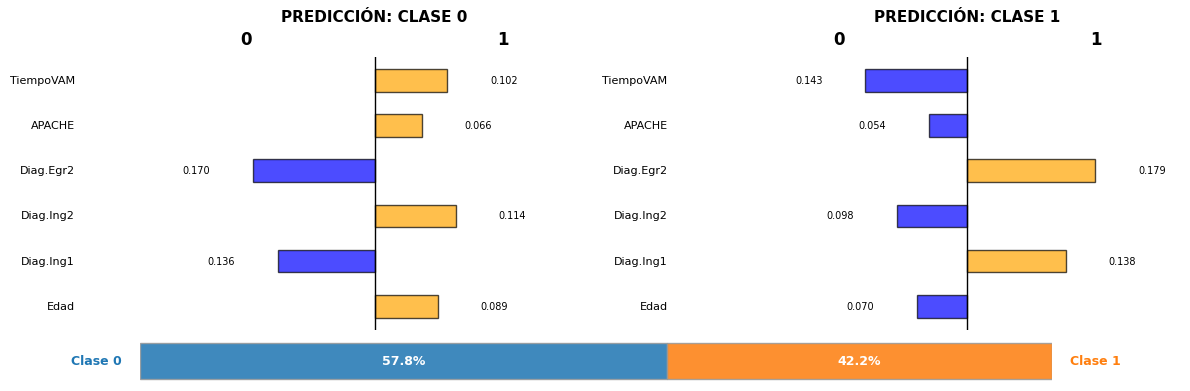

[[np.float64(0.000340266799984377), np.float64(-0.12110233563322152), np.float64(0.10945663421935983), np.float64(-0.16732187485100208), np.float64(-0.13271744394595061), np.float64(0.10637248288088455)], [np.float64(-0.029153814901157378), np.float64(0.13049981851005896), np.float64(-0.09427667228180836), np.float64(0.1769755557060764), np.float64(0.10650327650308872), np.float64(-0.1480889749950857)]]
-0.20497227052994546 0.14245918854117265


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/lime/lime_tabular.py:372: UserWarning: 
                    Prediction probabilties do not sum to 1, and
                    thus does not constitute a probability space.
                    Check that you classifier outputs probabilities
                    (Not log probabilities, or actual class predictions).
                    
  warnings.warn("""
/content/drive/MyDrive/Tesis/Mortalidad_Oculta/Meta-Explainer/aux_functions.py:406: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 0.95])


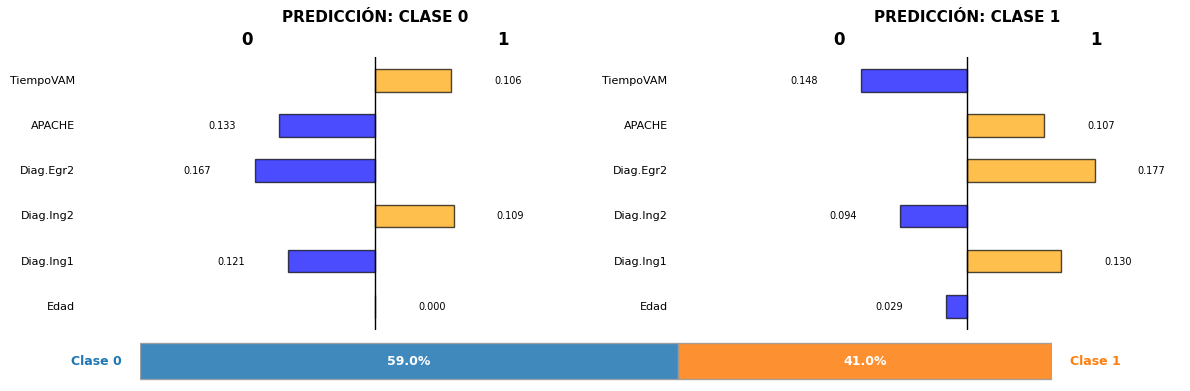

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(


[[np.float64(-0.016856192030689332), np.float64(-0.1284048099329551), np.float64(0.11099027821010306), np.float64(-0.17164145651781737), np.float64(0.07023629978519391), np.float64(0.0921311768840721)], [np.float64(-0.00696866793173382), np.float64(0.13277399315400817), np.float64(-0.09585685649919412), np.float64(0.18424470533775344), np.float64(-0.05798176302312474), np.float64(-0.1402387741218195)]]
-0.043544703602092755 0.015972636915889432


/usr/local/lib/python3.12/dist-packages/lime/lime_tabular.py:372: UserWarning: 
                    Prediction probabilties do not sum to 1, and
                    thus does not constitute a probability space.
                    Check that you classifier outputs probabilities
                    (Not log probabilities, or actual class predictions).
                    
  warnings.warn("""
/content/drive/MyDrive/Tesis/Mortalidad_Oculta/Meta-Explainer/aux_functions.py:406: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 0.95])


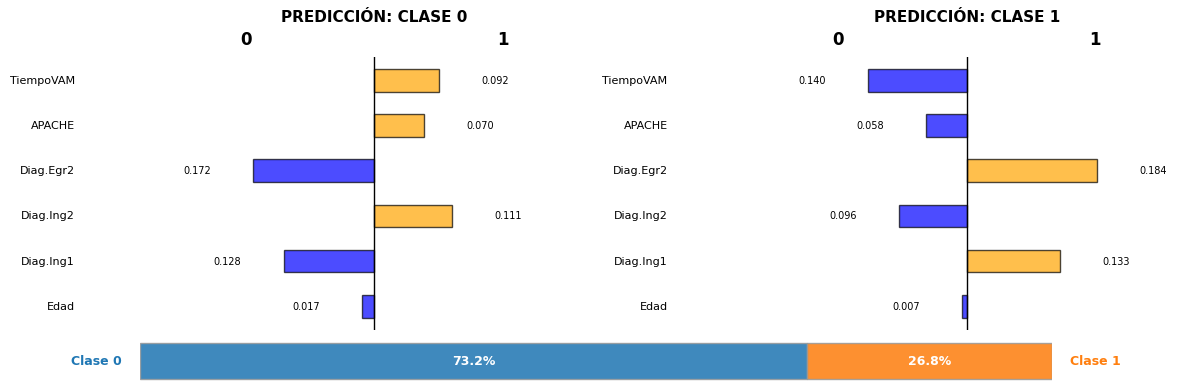

[[np.float64(0.09447776881616737), np.float64(0.008675309902475167), np.float64(0.12258853158620901), np.float64(-0.07085271948068958), np.float64(0.058414931008198154), np.float64(0.12350805162050067)], [np.float64(-0.07800019538981809), np.float64(-0.016118807181122477), np.float64(-0.10604533220507302), np.float64(0.06523606567527589), np.float64(-0.050375833676542726), np.float64(-0.16548752767064756)]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/lime/lime_tabular.py:372: UserWarning: 
                    Prediction probabilties do not sum to 1, and
                    thus does not constitute a probability space.
                    Check that you classifier outputs probabilities
                    (Not log probabilities, or actual class predictions).
                    
  warnings.warn("""
/content/drive/MyDrive/Tesis/Mortalidad_Oculta/Meta-Explainer/aux_functions.py:406: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 0.95])


0.3368118734528608 -0.35079163044792794


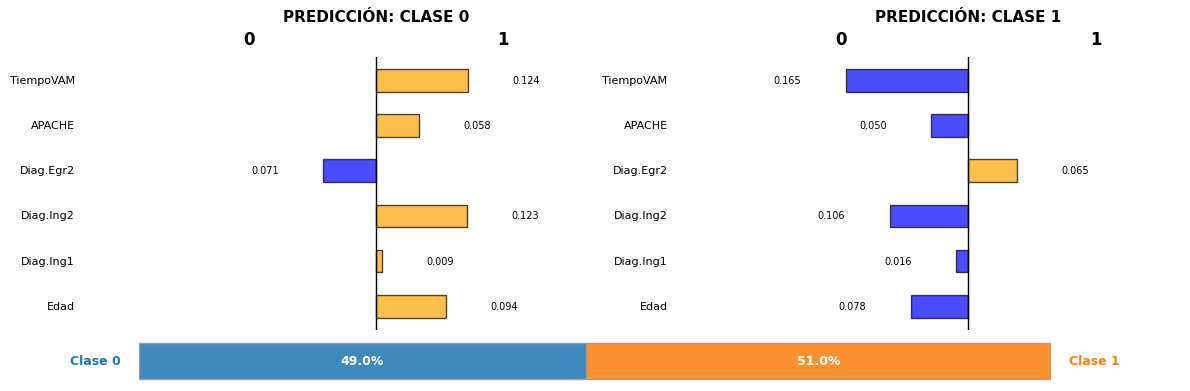

[[np.float64(-0.031117416732084926), np.float64(0.009690699411803047), np.float64(-0.06630387176742596), np.float64(0.04506576088217987), np.float64(-0.2269889478067145), np.float64(0.12460552651013121)], [np.float64(-0.0004160065098560313), np.float64(-0.02239345880753864), np.float64(0.05038138178578519), np.float64(-0.04924223231712426), np.float64(0.20882607313165286), np.float64(-0.16231422500752482)]]
-0.1450482495021113 0.02484153227539429


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/lime/lime_tabular.py:372: UserWarning: 
                    Prediction probabilties do not sum to 1, and
                    thus does not constitute a probability space.
                    Check that you classifier outputs probabilities
                    (Not log probabilities, or actual class predictions).
                    
  warnings.warn("""
/content/drive/MyDrive/Tesis/Mortalidad_Oculta/Meta-Explainer/aux_functions.py:406: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 0.95])


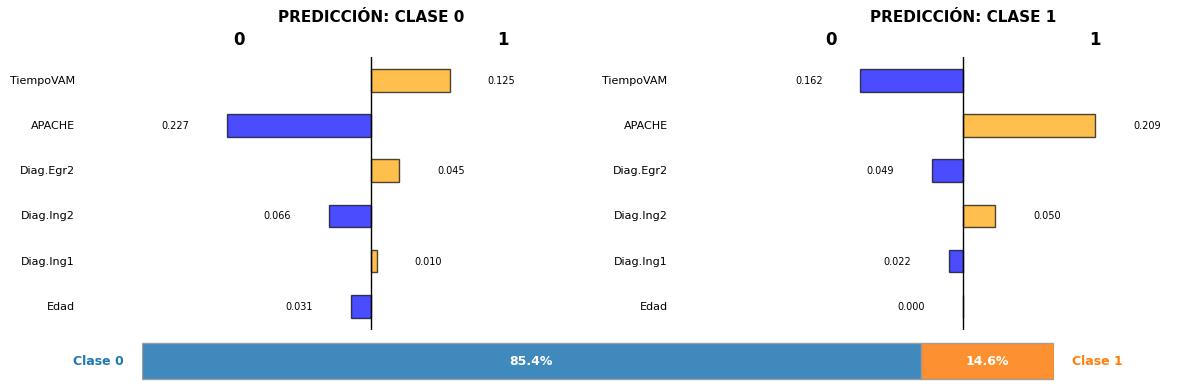

[[np.float64(-0.028595544269389383), np.float64(-0.11605135964671938), np.float64(0.11271209563005256), np.float64(0.052853861962676614), np.float64(-0.27276135609307084), np.float64(-0.19185643023550217)], [np.float64(0.044120032763460305), np.float64(0.12494637085057024), np.float64(-0.10083151318237596), np.float64(-0.05639167226115986), np.float64(0.24564111563179497), np.float64(0.27778360632485466)]]
-0.4436987326519526 0.5352679401271443


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/lime/lime_tabular.py:372: UserWarning: 
                    Prediction probabilties do not sum to 1, and
                    thus does not constitute a probability space.
                    Check that you classifier outputs probabilities
                    (Not log probabilities, or actual class predictions).
                    
  warnings.warn("""
/content/drive/MyDrive/Tesis/Mortalidad_Oculta/Meta-Explainer/aux_functions.py:406: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 0.95])


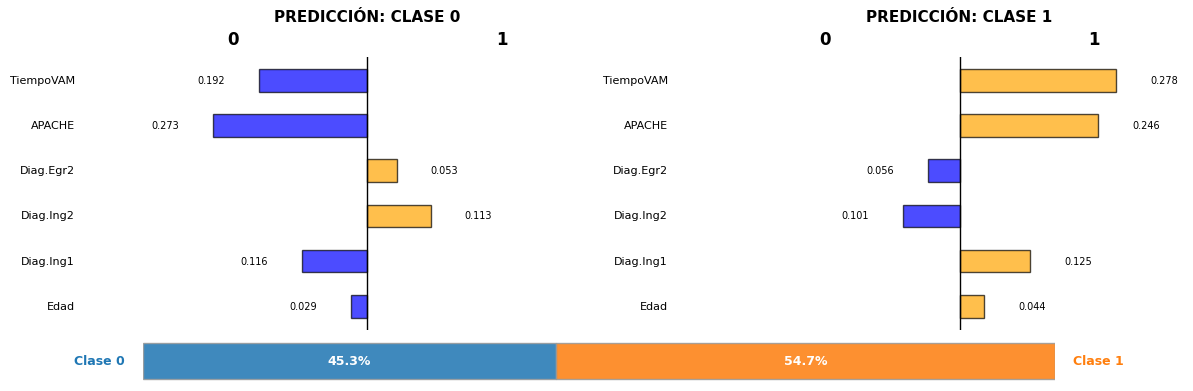

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(


[[np.float64(0.09445884645612788), np.float64(-0.1278258556954798), np.float64(0.10699112112827189), np.float64(0.20903693659054753), np.float64(-0.12236087131965456), np.float64(0.03761489546235402)], [np.float64(-0.07039892825534513), np.float64(0.14110037698684277), np.float64(-0.09662116730048444), np.float64(-0.21335590797702064), np.float64(0.101650076161143), np.float64(-0.05574391704932289)]]
0.19791507262216695 -0.19336946743418731


/usr/local/lib/python3.12/dist-packages/lime/lime_tabular.py:372: UserWarning: 
                    Prediction probabilties do not sum to 1, and
                    thus does not constitute a probability space.
                    Check that you classifier outputs probabilities
                    (Not log probabilities, or actual class predictions).
                    
  warnings.warn("""
/content/drive/MyDrive/Tesis/Mortalidad_Oculta/Meta-Explainer/aux_functions.py:406: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 0.95])


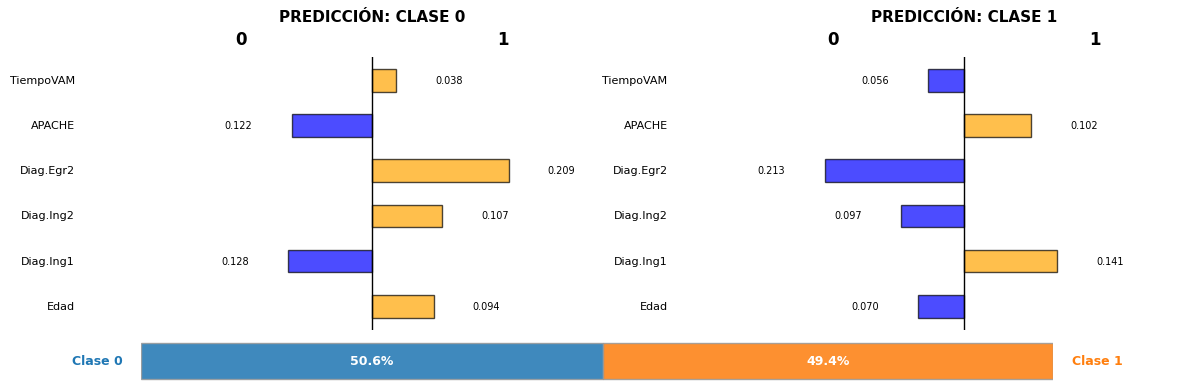

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/lime/lime_tabular.py:372: UserWarning: 
                    Prediction probabilties do not sum to 1, and
                    thus does not constitute a probability space.
                    Check that you classifier outputs probabilities
                    (Not log probabilities, or actual class predictions).
                    
  warnings.warn("""


[[np.float64(-0.03438810588861951), np.float64(0.006554956547572155), np.float64(-0.04151194935762342), np.float64(0.20192789564172559), np.float64(-0.2493319619221742), np.float64(0.01937852659308364)], [np.float64(0.003229704810193961), np.float64(-0.018693045029333926), np.float64(0.023752748372236267), np.float64(-0.20852256122349264), np.float64(0.2318635726156624), np.float64(-0.03632034108438783)]]
-0.09737063838603574 -0.004689921539121754


/content/drive/MyDrive/Tesis/Mortalidad_Oculta/Meta-Explainer/aux_functions.py:406: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 0.95])


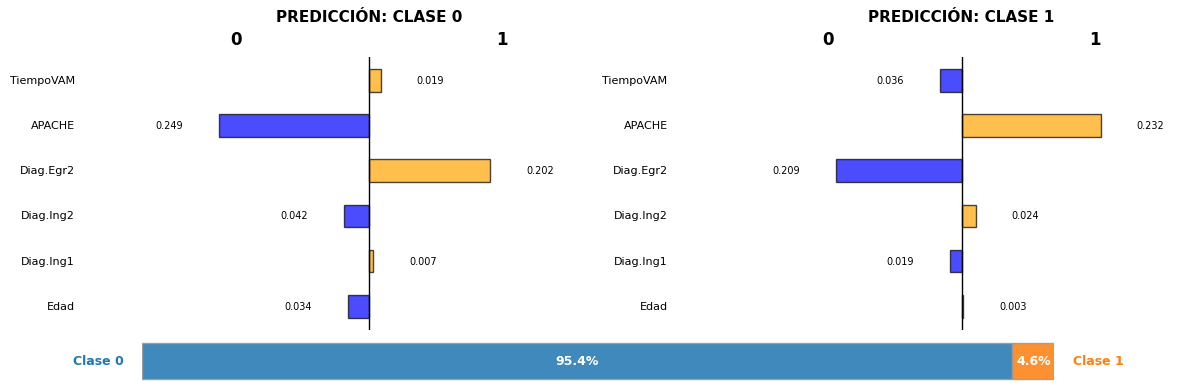

In [ ]:
lime_explanation = lime_explainer(X, instances_to_explain, model)

In [ ]:
save_explanations_to_pkl(lime_explanation, '/content/drive/MyDrive/Tesis/Mortalidad_Oculta/Meta-Explainer/Tabular/Relevance/explanations_pkl/lime_explanation.pkl')

Explanations saved to /content/drive/MyDrive/Tesis/Mortalidad_Oculta/Meta-Explainer/Tabular/Relevance/explanations_pkl/lime_explanation.pkl


## SHAP

[array([[-0.02362207497647662, -0.11293718085071822, 0.09056045112885472,
        -0.14619394786249146, 0.06520871876843817, 0.04247840026794975],
       [0.03907688670299544, 0.11728419317378125, -0.08454361743740464,
        0.14107019931179285, -0.0739549935949243, -0.05708838177047867]],
      dtype=object)]
-0.08450563352444365 0.08184428638576194


/content/drive/MyDrive/Tesis/Mortalidad_Oculta/Meta-Explainer/aux_functions.py:406: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 0.95])


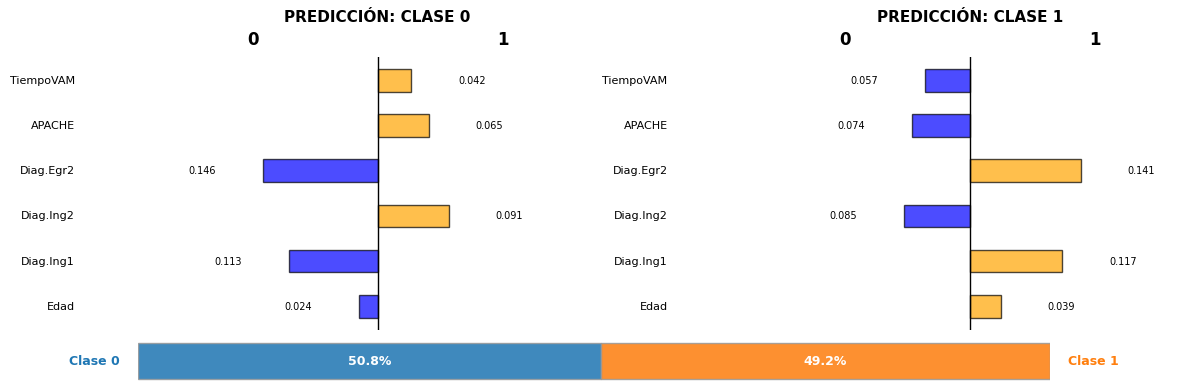

[array([[-0.02362207497647662, -0.11293718085071822, 0.09056045112885472,
        -0.14619394786249146, 0.06520871876843817, 0.04247840026794975],
       [0.03907688670299544, 0.11728419317378125, -0.08454361743740464,
        0.14107019931179285, -0.0739549935949243, -0.05708838177047867]],
      dtype=object), array([[0.09771636721759389, -0.05385057520578161, 0.13511589790116071,
        -0.1318435785033062, -0.07012112739292642, 0.0299600134897086],
       [-0.14754387357745366, 0.0420332512409099, -0.14808032633001575,
        0.11221483382753401, 0.04780536758531403, -0.04801322785334863]],
      dtype=object)]


/content/drive/MyDrive/Tesis/Mortalidad_Oculta/Meta-Explainer/aux_functions.py:406: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 0.95])


0.006976997506448965 -0.1415839751070601


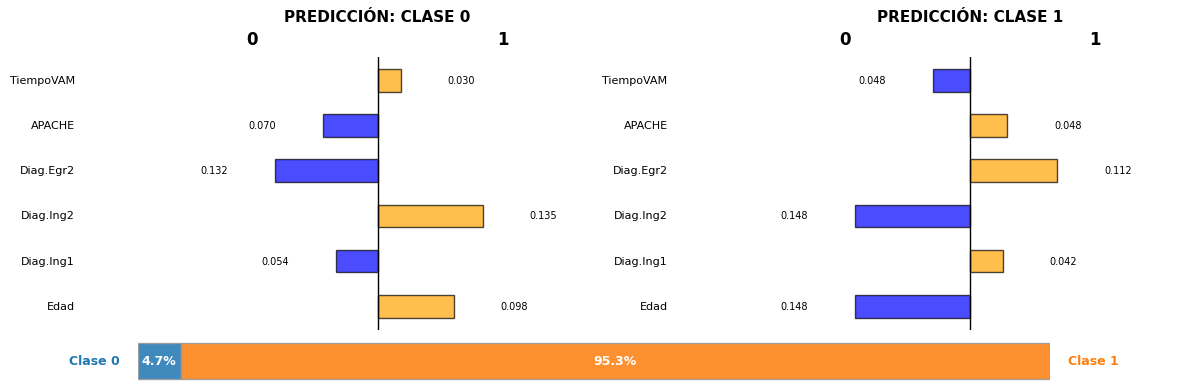

[array([[-0.02362207497647662, -0.11293718085071822, 0.09056045112885472,
        -0.14619394786249146, 0.06520871876843817, 0.04247840026794975],
       [0.03907688670299544, 0.11728419317378125, -0.08454361743740464,
        0.14107019931179285, -0.0739549935949243, -0.05708838177047867]],
      dtype=object), array([[0.09771636721759389, -0.05385057520578161, 0.13511589790116071,
        -0.1318435785033062, -0.07012112739292642, 0.0299600134897086],
       [-0.14754387357745366, 0.0420332512409099, -0.14808032633001575,
        0.11221483382753401, 0.04780536758531403, -0.04801322785334863]],
      dtype=object), array([[0.045299689746443224, -0.04474021740460829, 0.12146046490164952,
        -0.12064428060108032, 0.11617789056990017, 0.031531727442242474],
       [-0.060546219217951135, 0.037716818071484, -0.12163589731865147,
        0.10911490794215419, -0.10567414633616515, -0.046223091151041396]],
      dtype=object)]
0.1490852746545468 -0.18724762801017097


/content/drive/MyDrive/Tesis/Mortalidad_Oculta/Meta-Explainer/aux_functions.py:406: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 0.95])


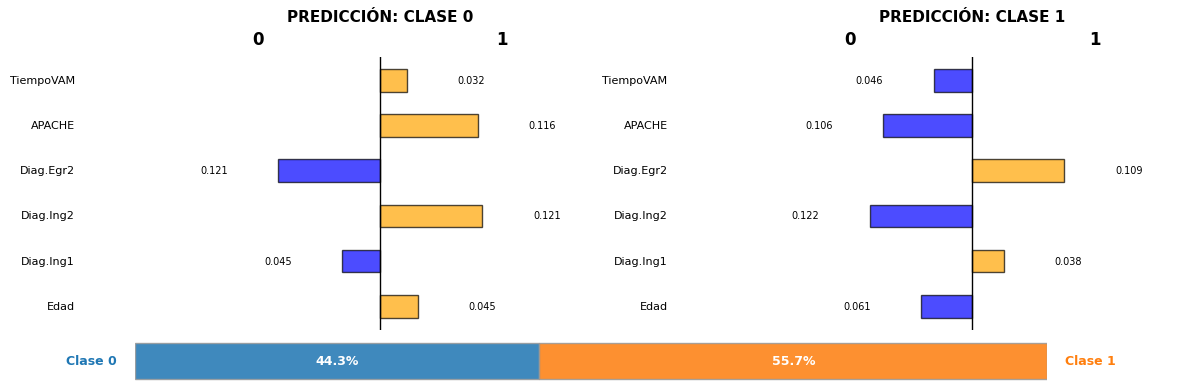

[array([[-0.02362207497647662, -0.11293718085071822, 0.09056045112885472,
        -0.14619394786249146, 0.06520871876843817, 0.04247840026794975],
       [0.03907688670299544, 0.11728419317378125, -0.08454361743740464,
        0.14107019931179285, -0.0739549935949243, -0.05708838177047867]],
      dtype=object), array([[0.09771636721759389, -0.05385057520578161, 0.13511589790116071,
        -0.1318435785033062, -0.07012112739292642, 0.0299600134897086],
       [-0.14754387357745366, 0.0420332512409099, -0.14808032633001575,
        0.11221483382753401, 0.04780536758531403, -0.04801322785334863]],
      dtype=object), array([[0.045299689746443224, -0.04474021740460829, 0.12146046490164952,
        -0.12064428060108032, 0.11617789056990017, 0.031531727442242474],
       [-0.060546219217951135, 0.037716818071484, -0.12163589731865147,
        0.10911490794215419, -0.10567414633616515, -0.046223091151041396]],
      dtype=object), array([[0.13311529023171514, 0.0651460085444276, 0.04008207

/content/drive/MyDrive/Tesis/Mortalidad_Oculta/Meta-Explainer/aux_functions.py:406: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 0.95])


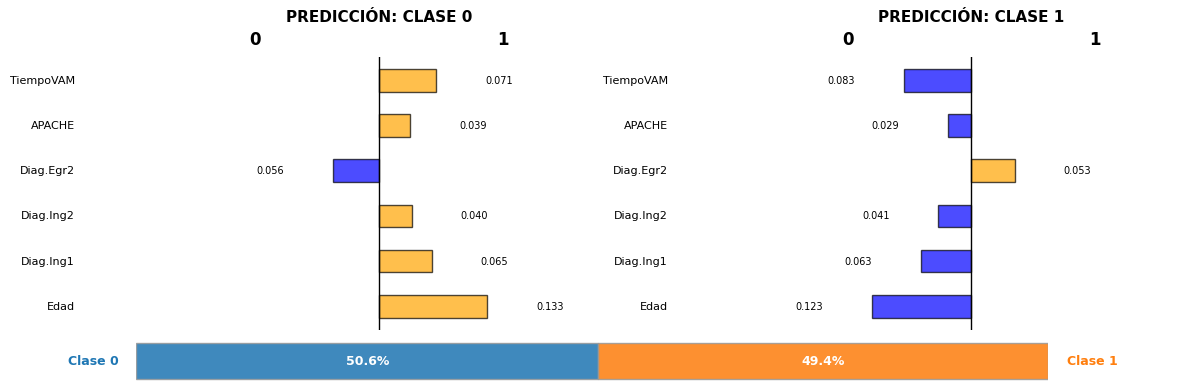

/content/drive/MyDrive/Tesis/Mortalidad_Oculta/Meta-Explainer/aux_functions.py:406: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 0.95])


[array([[-0.02362207497647662, -0.11293718085071822, 0.09056045112885472,
        -0.14619394786249146, 0.06520871876843817, 0.04247840026794975],
       [0.03907688670299544, 0.11728419317378125, -0.08454361743740464,
        0.14107019931179285, -0.0739549935949243, -0.05708838177047867]],
      dtype=object), array([[0.09771636721759389, -0.05385057520578161, 0.13511589790116071,
        -0.1318435785033062, -0.07012112739292642, 0.0299600134897086],
       [-0.14754387357745366, 0.0420332512409099, -0.14808032633001575,
        0.11221483382753401, 0.04780536758531403, -0.04801322785334863]],
      dtype=object), array([[0.045299689746443224, -0.04474021740460829, 0.12146046490164952,
        -0.12064428060108032, 0.11617789056990017, 0.031531727442242474],
       [-0.060546219217951135, 0.037716818071484, -0.12163589731865147,
        0.10911490794215419, -0.10567414633616515, -0.046223091151041396]],
      dtype=object), array([[0.13311529023171514, 0.0651460085444276, 0.04008207

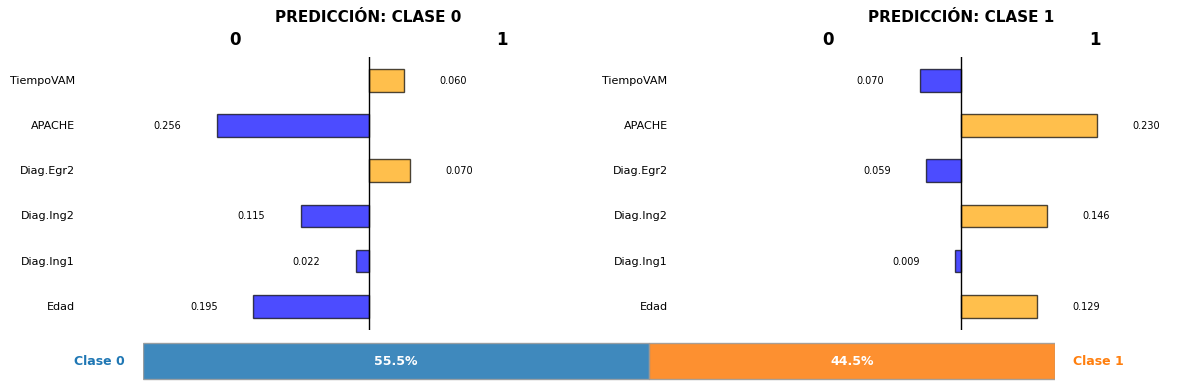

[array([[-0.02362207497647662, -0.11293718085071822, 0.09056045112885472,
        -0.14619394786249146, 0.06520871876843817, 0.04247840026794975],
       [0.03907688670299544, 0.11728419317378125, -0.08454361743740464,
        0.14107019931179285, -0.0739549935949243, -0.05708838177047867]],
      dtype=object), array([[0.09771636721759389, -0.05385057520578161, 0.13511589790116071,
        -0.1318435785033062, -0.07012112739292642, 0.0299600134897086],
       [-0.14754387357745366, 0.0420332512409099, -0.14808032633001575,
        0.11221483382753401, 0.04780536758531403, -0.04801322785334863]],
      dtype=object), array([[0.045299689746443224, -0.04474021740460829, 0.12146046490164952,
        -0.12064428060108032, 0.11617789056990017, 0.031531727442242474],
       [-0.060546219217951135, 0.037716818071484, -0.12163589731865147,
        0.10911490794215419, -0.10567414633616515, -0.046223091151041396]],
      dtype=object), array([[0.13311529023171514, 0.0651460085444276, 0.04008207

/content/drive/MyDrive/Tesis/Mortalidad_Oculta/Meta-Explainer/aux_functions.py:406: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 0.95])


-0.5203150789984687 0.5464575595481975


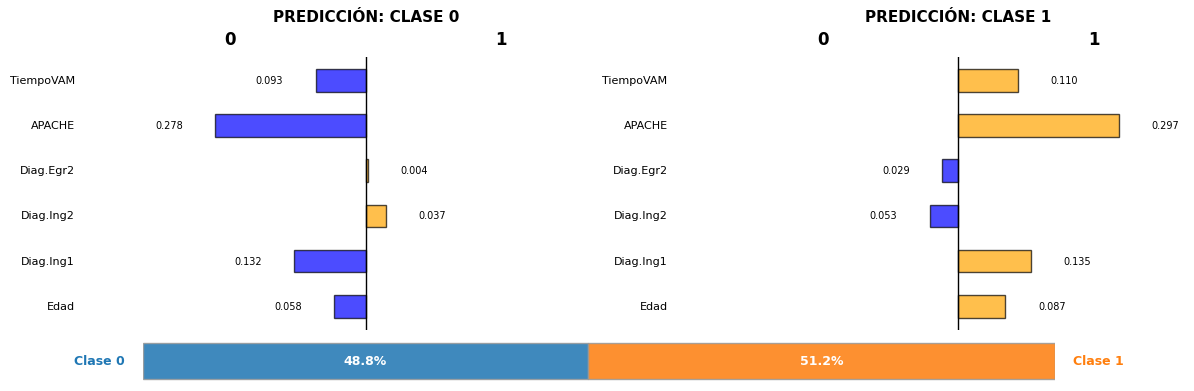

[array([[-0.02362207497647662, -0.11293718085071822, 0.09056045112885472,
        -0.14619394786249146, 0.06520871876843817, 0.04247840026794975],
       [0.03907688670299544, 0.11728419317378125, -0.08454361743740464,
        0.14107019931179285, -0.0739549935949243, -0.05708838177047867]],
      dtype=object), array([[0.09771636721759389, -0.05385057520578161, 0.13511589790116071,
        -0.1318435785033062, -0.07012112739292642, 0.0299600134897086],
       [-0.14754387357745366, 0.0420332512409099, -0.14808032633001575,
        0.11221483382753401, 0.04780536758531403, -0.04801322785334863]],
      dtype=object), array([[0.045299689746443224, -0.04474021740460829, 0.12146046490164952,
        -0.12064428060108032, 0.11617789056990017, 0.031531727442242474],
       [-0.060546219217951135, 0.037716818071484, -0.12163589731865147,
        0.10911490794215419, -0.10567414633616515, -0.046223091151041396]],
      dtype=object), array([[0.13311529023171514, 0.0651460085444276, 0.04008207

/content/drive/MyDrive/Tesis/Mortalidad_Oculta/Meta-Explainer/aux_functions.py:406: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 0.95])


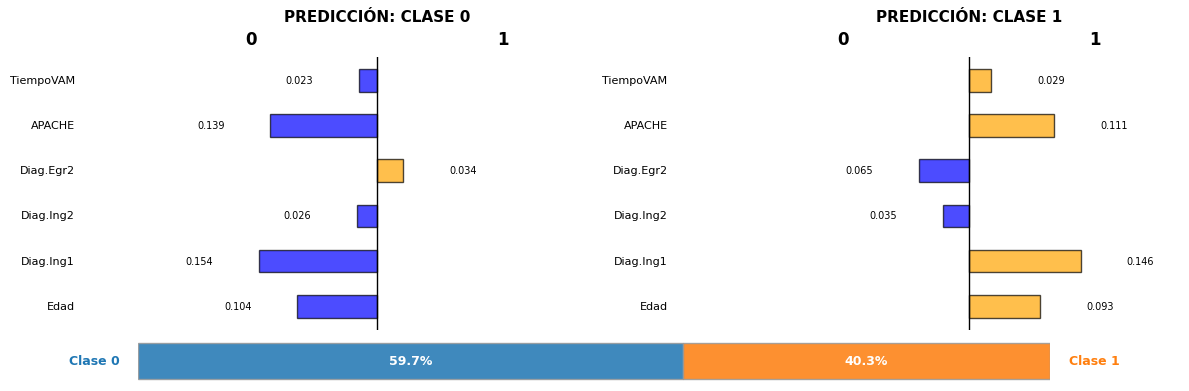

[array([[-0.02362207497647662, -0.11293718085071822, 0.09056045112885472,
        -0.14619394786249146, 0.06520871876843817, 0.04247840026794975],
       [0.03907688670299544, 0.11728419317378125, -0.08454361743740464,
        0.14107019931179285, -0.0739549935949243, -0.05708838177047867]],
      dtype=object), array([[0.09771636721759389, -0.05385057520578161, 0.13511589790116071,
        -0.1318435785033062, -0.07012112739292642, 0.0299600134897086],
       [-0.14754387357745366, 0.0420332512409099, -0.14808032633001575,
        0.11221483382753401, 0.04780536758531403, -0.04801322785334863]],
      dtype=object), array([[0.045299689746443224, -0.04474021740460829, 0.12146046490164952,
        -0.12064428060108032, 0.11617789056990017, 0.031531727442242474],
       [-0.060546219217951135, 0.037716818071484, -0.12163589731865147,
        0.10911490794215419, -0.10567414633616515, -0.046223091151041396]],
      dtype=object), array([[0.13311529023171514, 0.0651460085444276, 0.04008207

/content/drive/MyDrive/Tesis/Mortalidad_Oculta/Meta-Explainer/aux_functions.py:406: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 0.95])


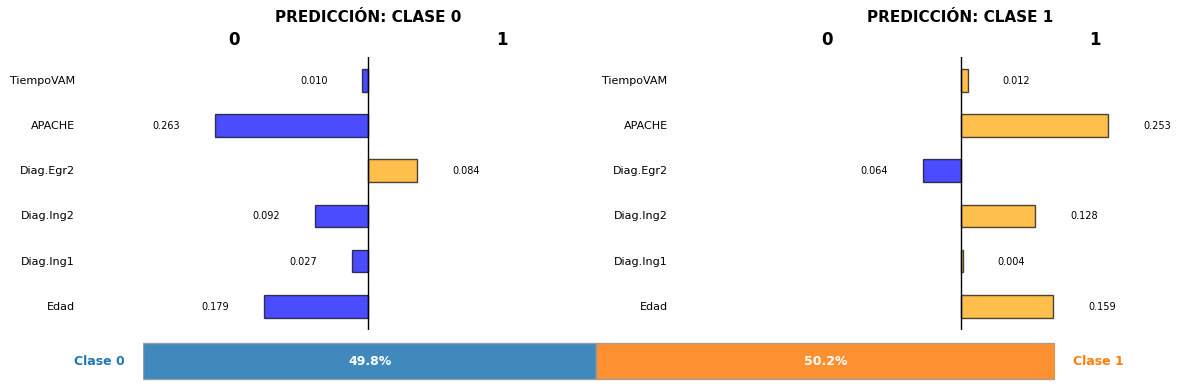

In [ ]:
shap_explanation = shap_explainer(X, instances_to_explain, model)

In [ ]:
save_explanations_to_pkl(shap_explanation, '/content/drive/MyDrive/Tesis/Mortalidad_Oculta/Meta-Explainer/Tabular/Relevance/explanations_pkl/shap_explanation.pkl')

Explanations saved to /content/drive/MyDrive/Tesis/Mortalidad_Oculta/Meta-Explainer/Tabular/Relevance/explanations_pkl/shap_explanation.pkl


## Integrated Gradients

[[-0.50272286  0.12824316 -0.          0.         -0.1765208  -0.12669589]
 [ 0.50272286 -0.12824316  0.         -0.          0.1765208   0.12669589]]
-0.67769635 0.67769635


/content/drive/MyDrive/Tesis/Mortalidad_Oculta/Meta-Explainer/aux_functions.py:406: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 0.95])


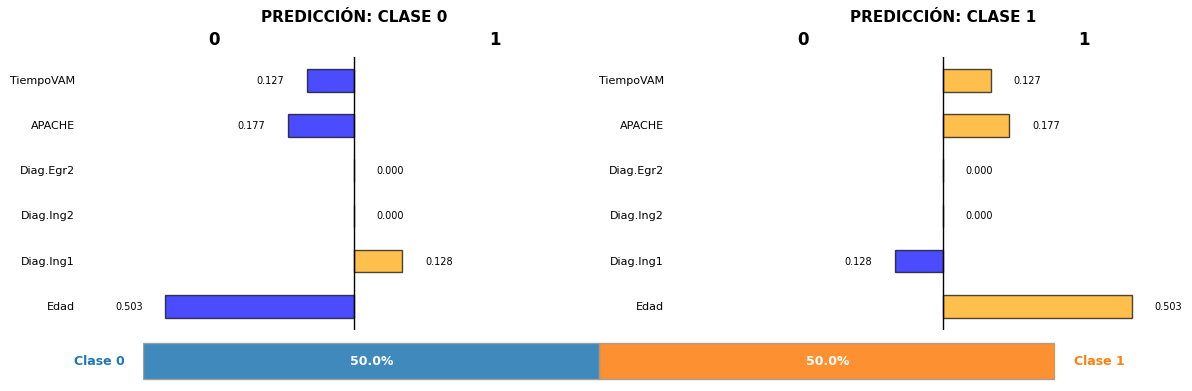

[[-0.3266757   0.20741382 -0.          0.         -0.37905085 -0.03568542]
 [ 0.3266757  -0.20741382  0.         -0.          0.37905085  0.03568542]]
-0.53399813 0.53399813


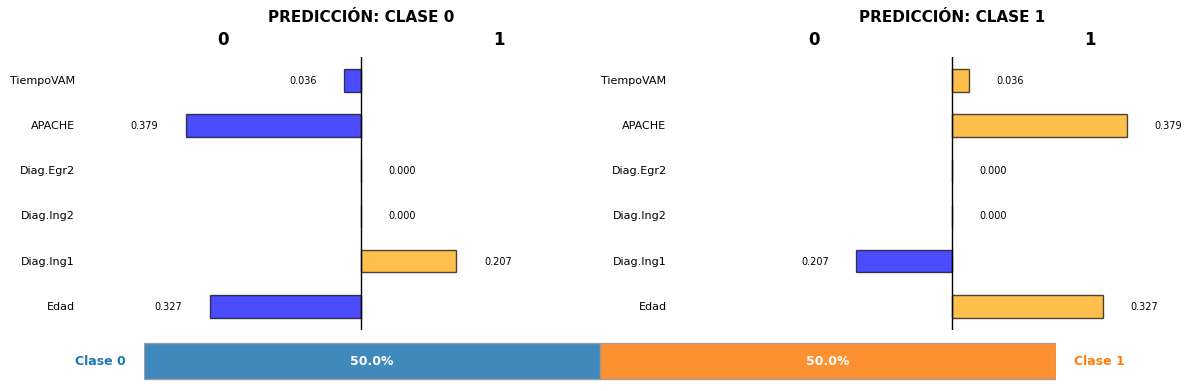

[[-0.5023941   0.28599662 -0.          0.         -0.14735465 -0.03752099]
 [ 0.50239414 -0.28599662  0.         -0.          0.14735465  0.03752099]]
-0.40127313 0.4012732


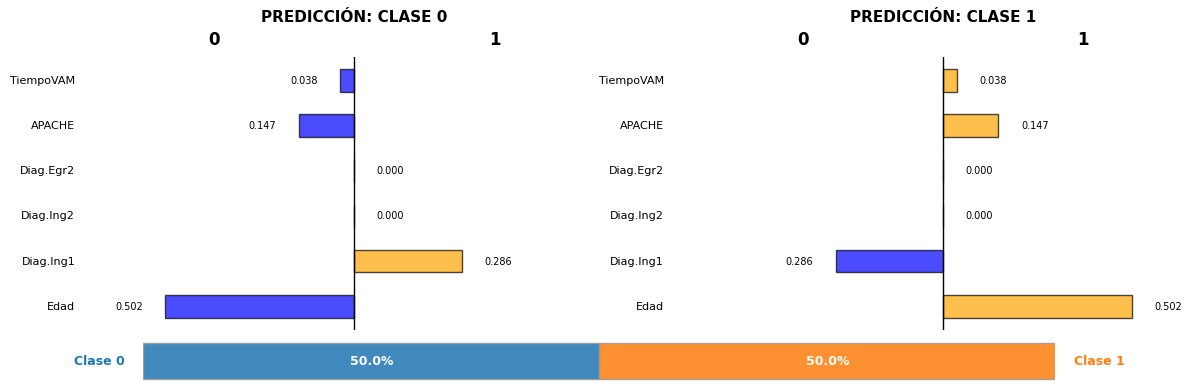

[[-0.21833892  0.15801594 -0.          0.11498074 -0.0569321  -0.01181412]
 [ 0.21833897 -0.15801594  0.         -0.11498074  0.05693208  0.01181411]]
-0.014088457 0.014088485


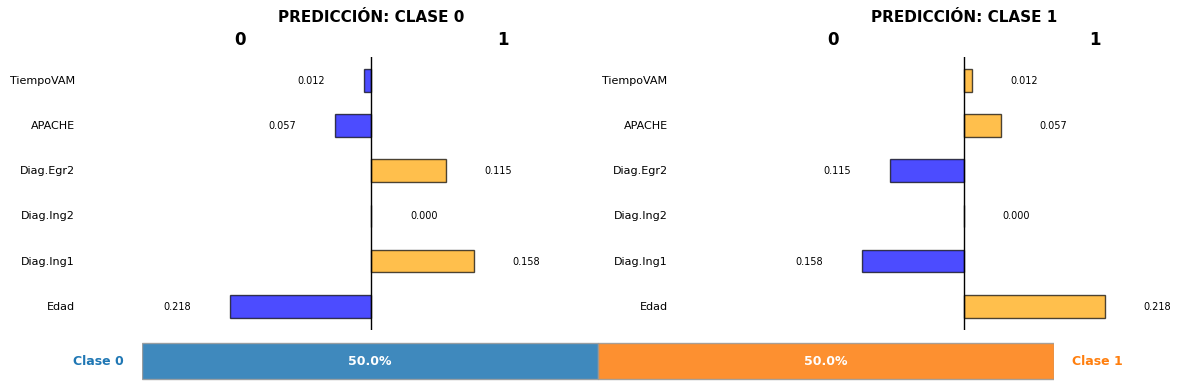

[[-2.5292559   1.6658459  -0.63675684  0.89352936  0.0861527  -0.17369702]
 [ 2.5292556  -1.665846    0.6367569  -0.89352936 -0.08615267  0.17369702]]
-0.6941818 0.69418156


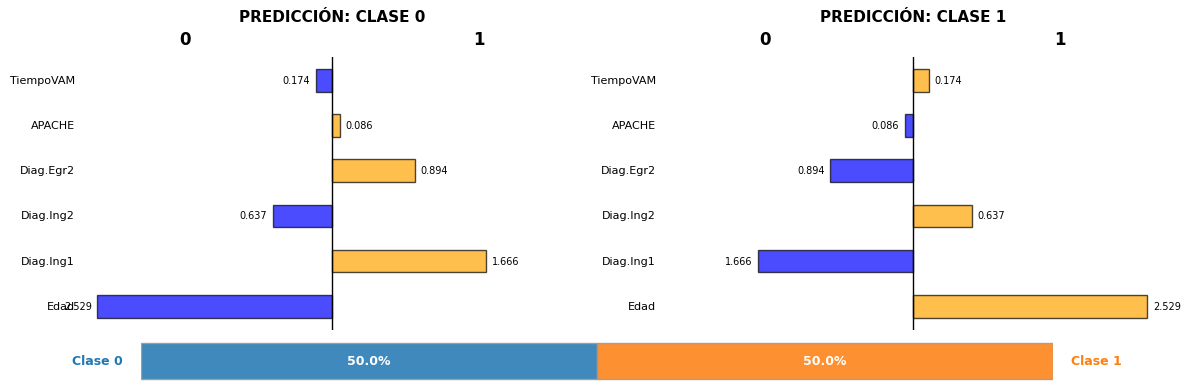

[[-2.3939886   0.19380791 -0.          1.5072799   0.5180202  -0.6988435 ]
 [ 2.3939886  -0.19380791  0.         -1.5072798  -0.5180203   0.69884354]]
-0.87372416 0.8737243


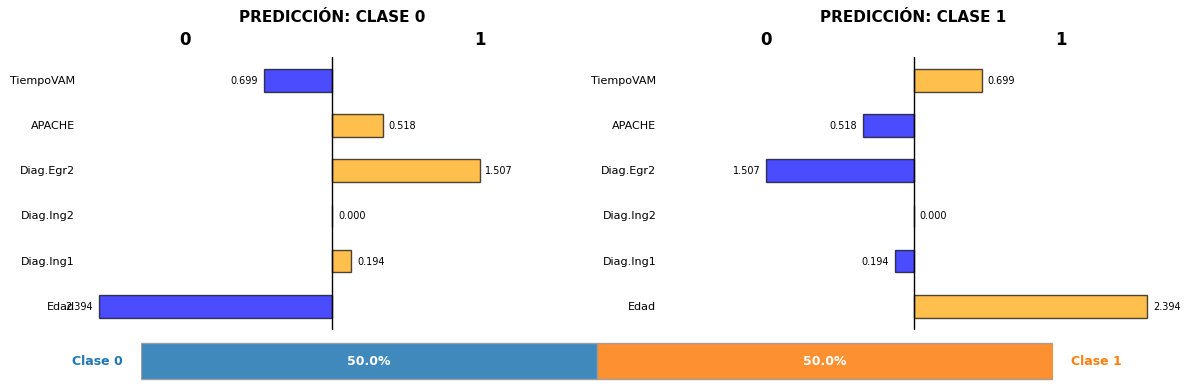

[[-2.4254584   0.30738103 -0.          1.7435454   0.3607496  -0.2770754 ]
 [ 2.4254587  -0.30738097  0.         -1.7435454  -0.36074954  0.2770754 ]]
-0.29085767 0.2908582


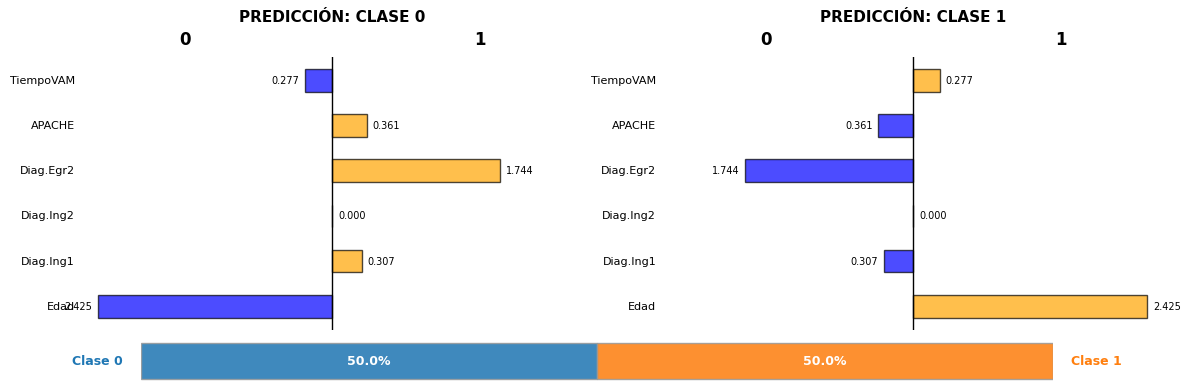

[[-0.78314567  1.4620607  -0.7131674   0.51913327 -0.5109506  -0.6529038 ]
 [ 0.7831456  -1.4620607   0.7131674  -0.5191333   0.5109506   0.6529038 ]]
-0.67897356 0.67897344


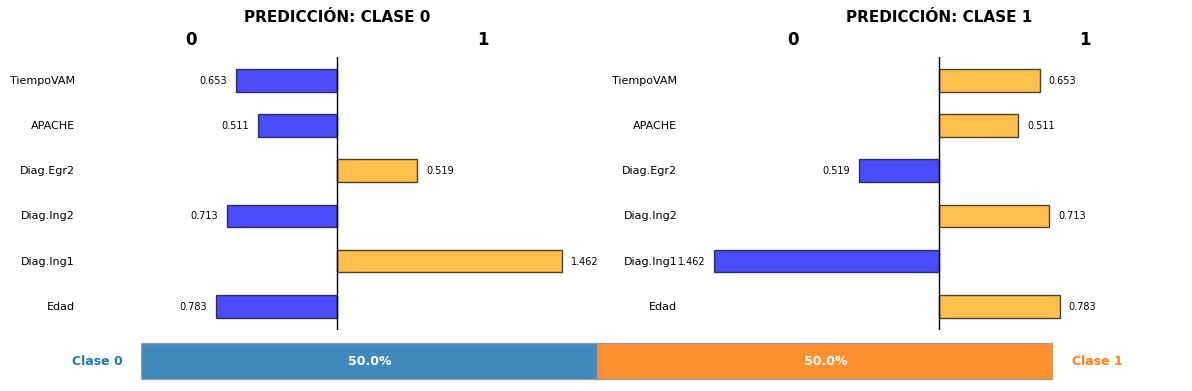

In [ ]:
ig_explanation = ig_explainer(X, instances_to_explain, model)

In [ ]:
save_explanations_to_pkl(ig_explanation, "/content/drive/MyDrive/Tesis/Mortalidad_Oculta/Meta-Explainer/Tabular/Relevance/explanations_pkl/ig_explanation.pkl")

Explanations saved to /content/drive/MyDrive/Tesis/Mortalidad_Oculta/Meta-Explainer/Tabular/Relevance/explanations_pkl/ig_explanation.pkl


## Saliency Maps

/usr/local/lib/python3.12/dist-packages/captum/attr/_core/saliency.py:129: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  gradient_mask = apply_gradient_requirements(inputs_tuple)


[[ 0.00359376  0.08724499 -0.069407    0.02759571 -0.02374608 -0.00613964]
 [-0.00359376 -0.08724499  0.069407   -0.02759571  0.02374608  0.00613964]]
0.019141737 -0.019141737


/content/drive/MyDrive/Tesis/Mortalidad_Oculta/Meta-Explainer/aux_functions.py:406: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 0.95])


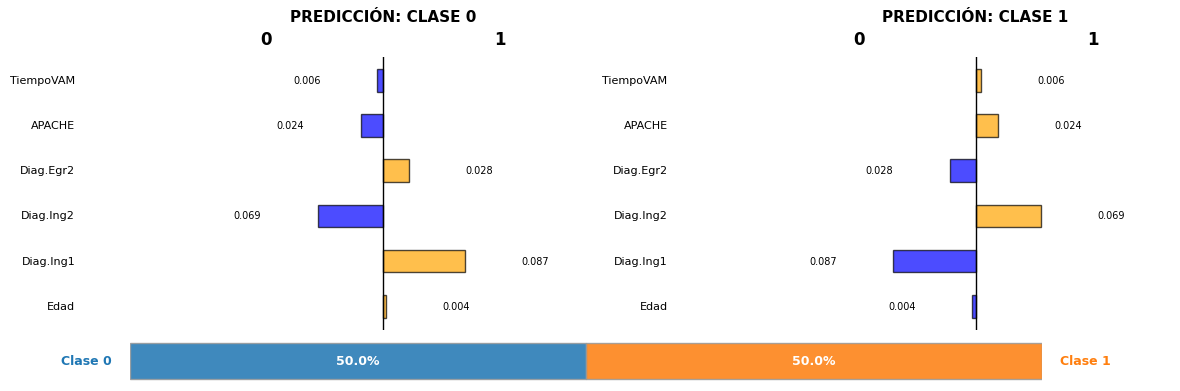

[[ 0.00427022  0.08099252 -0.0600958   0.02793361 -0.02868195 -0.00198866]
 [-0.00427022 -0.08099252  0.0600958  -0.02793361  0.02868196  0.00198866]]
0.022429941 -0.022429932


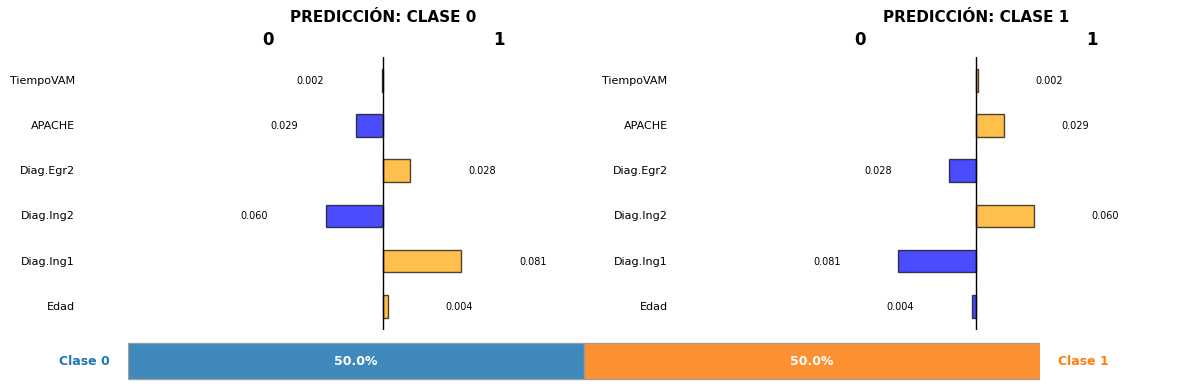

[[ 9.9896768e-04  2.0220734e-02 -1.5478357e-02  6.2892898e-03
  -5.9266482e-03  4.4637040e-05]
 [-9.9896768e-04 -2.0220734e-02  1.5478357e-02 -6.2892898e-03
   5.9266482e-03 -4.4637040e-05]]
0.006148624 -0.006148624


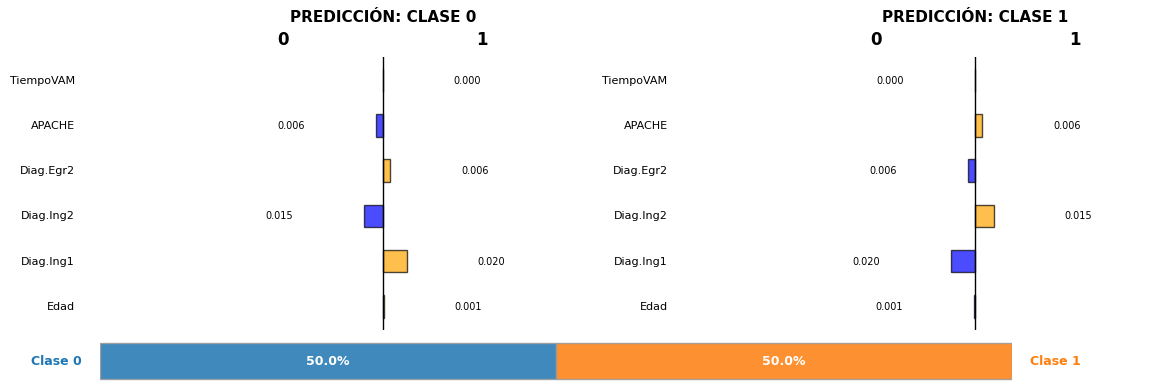

[[-8.0886530e-03  9.4851265e-03 -5.1504583e-03  1.8992819e-02
  -7.1641625e-06 -1.9460568e-03]
 [ 8.0886418e-03 -9.4851162e-03  5.1504560e-03 -1.8992804e-02
   7.1697305e-06  1.9460518e-03]]
0.013285614 -0.0132856015


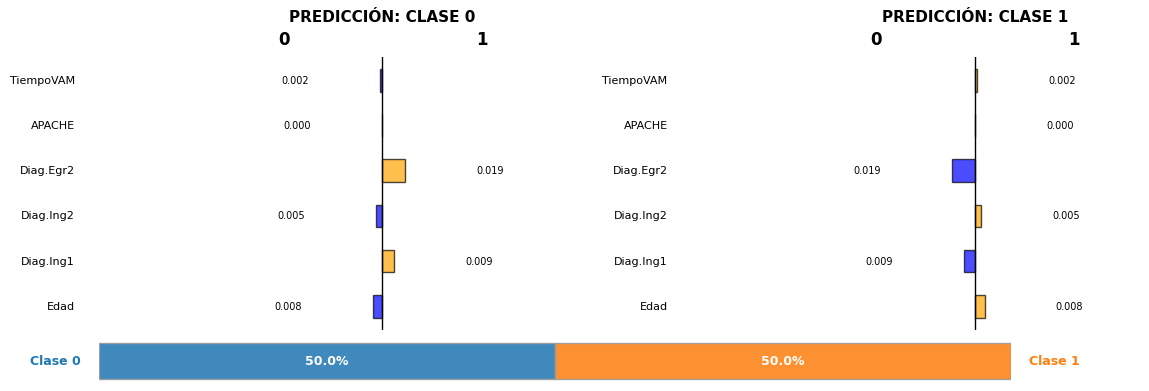

[[-0.00651089  0.06167028 -0.0276818   0.01297578 -0.00688018 -0.02034857]
 [ 0.00651089 -0.06167028  0.0276818  -0.01297578  0.00688018  0.02034857]]
0.013224628 -0.013224624


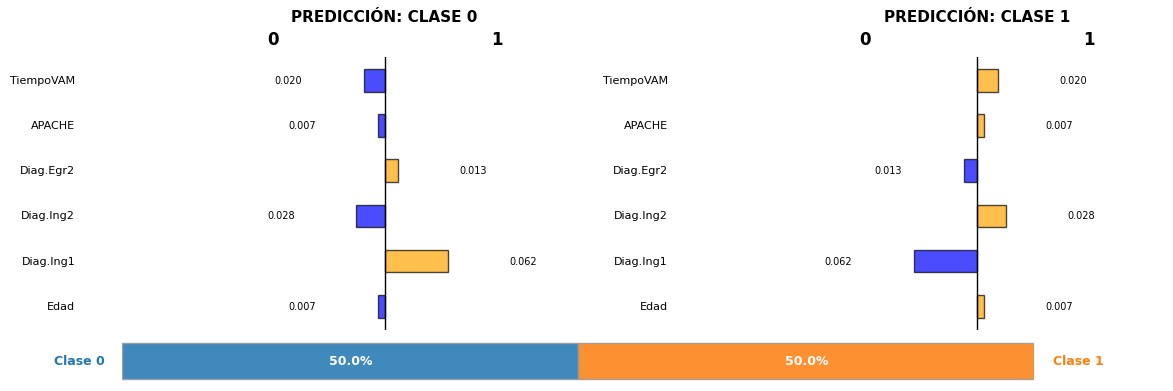

[[-0.02061957  0.02846832 -0.01780456  0.02590912  0.02692869 -0.02636937]
 [ 0.02061957 -0.02846833  0.01780456 -0.02590912 -0.02692869  0.02636937]]
0.016512638 -0.01651264


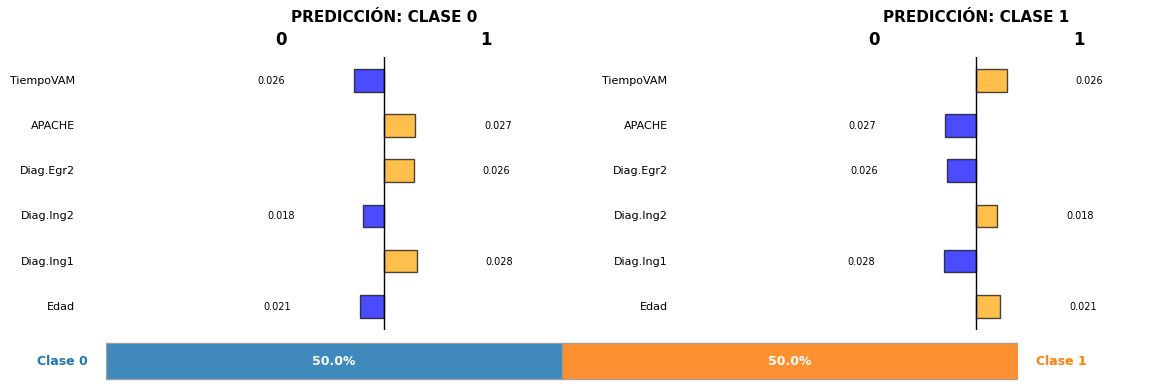

[[-0.11427834  0.18732119 -0.08423682  0.19232604  0.05834298 -0.07495232]
 [ 0.11427833 -0.18732123  0.08423683 -0.19232605 -0.05834298  0.07495234]]
0.16452274 -0.16452277


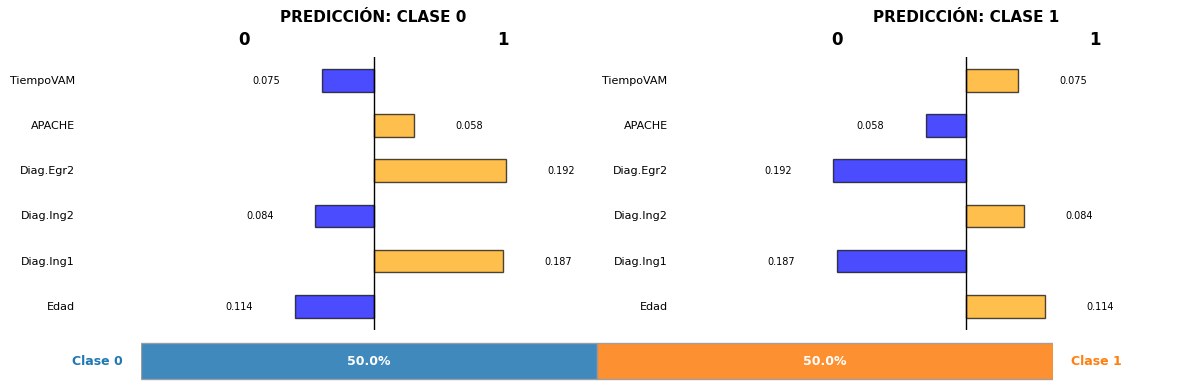

[[-0.00926209  0.0989936  -0.03719123  0.01014241  0.00415201 -0.13068278]
 [ 0.0092621  -0.09899361  0.03719122 -0.01014242 -0.00415202  0.13068281]]
-0.06384808 0.063848086


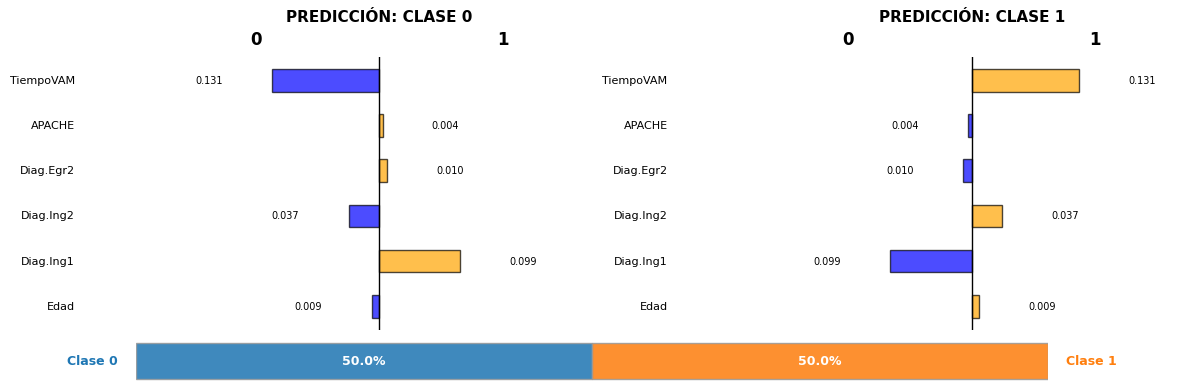

In [ ]:
saliencymaps_explanation = saliencymaps_explainer(X, instances_to_explain, model)

In [ ]:
save_explanations_to_pkl(saliencymaps_explanation, "/content/drive/MyDrive/Tesis/Mortalidad_Oculta/Meta-Explainer/Tabular/Relevance/explanations_pkl/saliencymaps_explanation.pkl")

Explanations saved to /content/drive/MyDrive/Tesis/Mortalidad_Oculta/Meta-Explainer/Tabular/Relevance/explanations_pkl/saliencymaps_explanation.pkl


## Calcular metricas

In [15]:
# List of paths to explanation files
explanation_paths = [
    "Tabular/Relevance/explanations_pkl/lime_explanation.pkl",
    "Tabular/Relevance/explanations_pkl/shap_explanation.pkl",
    "Tabular/Relevance/explanations_pkl/ig_explanation.pkl",
    "Tabular/Relevance/explanations_pkl/saliencymaps_explanation.pkl"
]

# Load the explanations
explanations = [load_explanations_from_pkl(path) for path in explanation_paths]

Explanations loaded from Tabular/Relevance/explanations_pkl/lime_explanation.pkl
Explanations loaded from Tabular/Relevance/explanations_pkl/shap_explanation.pkl
Explanations loaded from Tabular/Relevance/explanations_pkl/ig_explanation.pkl
Explanations loaded from Tabular/Relevance/explanations_pkl/saliencymaps_explanation.pkl


In [16]:
from Metrics.lse import lse
#from Metrics.fidelity import fidelity
#list of metrics to find
# fidelity, faithfulnessEstimate, pixelFlipping, complexity, sparseness, lse
metrics = [fidelity, faithfulnessEstimate, pixelFlipping, complexity, sparseness, lse]
kwargs = {
    'feature_stds': X.std(),
}

In [17]:
import torch
model_pt = transfer_to_pytorch(model)
model_pt.eval()
with torch.no_grad():
    X_test_tensor = torch.tensor(X.values, dtype=torch.float32)
    instance = X_test_tensor[0].unsqueeze(0)
    salida = model_pt(instance)
    print(salida)
    clase_predicha = torch.argmax(salida, dim=1).item()
    print(clase_predicha)

tensor([[0.2907, 0.7093]])
1


In [26]:
print(X.iloc[instances_to_explain])

    Edad  Diag.Ing1  Diag.Ing2  Diag.Egr2  APACHE  TiempoVAM
0     35          1          0          0      10          2
1     87          2          0          0      16          2
2     70          4          0          0      11          2
3     24         13          0          5      11          2
12    86         14         18         16      21          2
13    50          2          0         16      24          9
14    42          3          0         17      16          5
18    74         14         17         17      22          5


In [18]:
evaluate_explanations_lime = evaluate_explanations(explanations[0],
                                                metrics,
                                                model_pt,
                                                instances_to_explain,
                                                X,
                                                y, **kwargs)

fidelity: [np.float64(0.996), np.float64(0.899), np.float64(0.912), np.float64(0.934), np.float64(0.9458), np.float64(0.9548333333333333), np.float64(0.9167142857142857), np.float64(0.917625)]

faithfulnessEstimate: [0.6466277837753296, 0.692881166934967, 0.41821855306625366, 0.39303058385849, 0.12246949970722198, 0.27570122480392456, 0.6311631202697754, 0.046332307159900665]

pixelFlipping: [0.5094189643859863, 0.6073929071426392, 0.7949767112731934, 4.726213455200195, 1.6558072566986084, 1.6147477626800537, 0.5346071124076843, 1.371262550354004]

complexity: [np.float32(1.748105), np.float32(1.5988212), np.float32(1.6499798), np.float32(1.6310346), np.float32(1.3388474), np.float32(1.5927006), np.float32(1.6923654), np.float32(1.203622)]

sparseness: [np.float64(0.16604332719020393), np.float64(0.24205565760104888), np.float64(0.2731255106155295), np.float64(0.27526319395112364), np.float64(0.49399994257797836), np.float64(0.34524952953325394), np.float64(0.24678080030151708), np.flo

/usr/local/lib/python3.12/dist-packages/quantus/helpers/model/pytorch_model.py:181: UserWarning: The combination of the value of the passed softmax argument and the passed model potentially requires adjusting the model's modules. Make sure that the torch.nn.Softmax layer is the last module in the list of model's children (self.model.modules()) if and only if it is the actual last module applied beforeoutput.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/quantus/helpers/warn.py:257: UserWarning: The settings for perturbing input e.g., 'perturb_func' didn't cause change in input. Reconsider the parameter settings.
  warnings.warn(


In [19]:
lime_explanations_data = {
    'explanations': explanations[0],
    'metric': evaluate_explanations_lime
}

save_explanations_to_pkl(lime_explanations_data, "Tabular/Relevance/explanations_with_metrics_pkl/lime_explanation_data.pkl")


Explanations saved to Tabular/Relevance/explanations_with_metrics_pkl/lime_explanation_data.pkl


In [20]:
evaluate_explanations_shap = evaluate_explanations(explanations[1],
                                                metrics,
                                                model_pt,
                                                instances_to_explain,
                                                X,
                                                y)

fidelity: [np.float64(0.996), np.float64(0.953), np.float64(0.963), np.float64(0.97225), np.float64(0.9778), np.float64(0.9815), np.float64(0.9458571428571428), np.float64(0.952625)]

faithfulnessEstimate: [0.6716309785842896, 0.7832050323486328, 0.464468389749527, -0.0058312080800533295, 0.09554357826709747, 0.41328245401382446, 0.7645316123962402, 0.2542016804218292]

pixelFlipping: [0.7571039199829102, 1.0313537120819092, 0.9245752096176147, 4.807883262634277, 1.6558072566986084, 0.9558497667312622, 0.12733100354671478, 0.6488240957260132]

complexity: [np.float32(1.6498194), np.float32(1.6835322), np.float32(1.6611981), np.float32(1.693629), np.float32(1.5484612), np.float32(1.5503867), np.float32(1.6504366), np.float32(1.3834165)]

sparseness: [np.float64(0.2943817600219228), np.float64(0.2530344094492762), np.float64(0.2598823197013521), np.float64(0.23613075411073886), np.float64(0.3689779441576283), np.float64(0.3767204372758549), np.float64(0.2931919465342774), np.float64(0.47

In [21]:
shap_explanations_data = {
    'explanations': explanations[1],
    'metric': evaluate_explanations_shap
}

save_explanations_to_pkl(shap_explanations_data, "Tabular/Relevance/explanations_with_metrics_pkl/shap_explanation_data.pkl")


Explanations saved to Tabular/Relevance/explanations_with_metrics_pkl/shap_explanation_data.pkl


In [22]:
evaluate_explanations_ig = evaluate_explanations(explanations[2],
                                                metrics,
                                                model_pt,
                                                instances_to_explain,
                                                X,
                                                y)

fidelity: [np.float64(0.997), np.float64(0.9155), np.float64(0.93), np.float64(0.9475), np.float64(0.9556), np.float64(0.962), np.float64(0.9278571428571428), np.float64(0.9355)]

faithfulnessEstimate: [-0.14044612646102905, -0.15664084255695343, -0.30496326088905334, 0.46464237570762634, 0.16676732897758484, 0.43159762024879456, 0.09246370196342468, -0.1315179318189621]

pixelFlipping: [1.753322958946228, 2.7885637283325195, 2.054029703140259, 4.083508014678955, 0.19028565287590027, 1.25367271900177, 0.9539474248886108, 0.1955147683620453]

complexity: [np.float32(1.1918547), np.float32(1.1894284), np.float32(1.1125536), np.float32(1.3630738), np.float32(1.4060477), np.float32(1.331258), np.float32(1.2346507), np.float32(1.7157593)]

sparseness: [np.float64(0.5432054485552996), np.float64(0.5352238092408321), np.float64(0.5958951888800735), np.float64(0.4726525332863879), np.float64(0.4719592307789249), np.float64(0.5048744323641665), np.float64(0.5403267342645096), np.float64(0.20137

In [23]:
ig_explanations_data = {
    'explanations': explanations[2],
    'metric': evaluate_explanations_ig
}

save_explanations_to_pkl(ig_explanations_data, "Tabular/Relevance/explanations_with_metrics_pkl/ig_explanation_data.pkl")


Explanations saved to Tabular/Relevance/explanations_with_metrics_pkl/ig_explanation_data.pkl


In [24]:
evaluate_explanations_saliencymaps = evaluate_explanations(explanations[3],
                                                metrics,
                                                model_pt,
                                                instances_to_explain,
                                                X,
                                                y)

fidelity: [np.float64(0.992), np.float64(0.885), np.float64(0.9016666666666666), np.float64(0.92625), np.float64(0.9346), np.float64(0.9455), np.float64(0.9101428571428571), np.float64(0.907625)]

faithfulnessEstimate: [-0.912170946598053, -0.811587929725647, -0.7234731316566467, -0.1348276287317276, -0.596167802810669, -0.2467048019170761, -0.4761880040168762, -0.5601484775543213]

pixelFlipping: [4.638000965118408, 4.353492259979248, 4.336724281311035, 4.737127304077148, 2.795973062515259, 3.51495099067688, 0.9436732530593872, 1.8358128070831299]

complexity: [np.float32(1.4027369), np.float32(1.4010295), np.float32(1.3342992), np.float32(1.3982464), np.float32(1.4872514), np.float32(1.7789919), np.float32(1.6935227), np.float32(1.2771499)]

sparseness: [np.float64(0.4684053999543236), np.float64(0.46025068425422), np.float64(0.49252787818801497), np.float64(0.459822098173359), np.float64(0.4232878182257909), np.float64(0.08294156033878318), np.float64(0.24294331579208792), np.float6

In [25]:
saliencymaps_explanations_data = {
    'explanations': explanations[3],
    'metric': evaluate_explanations_saliencymaps
}

save_explanations_to_pkl(saliencymaps_explanations_data, "Tabular/Relevance/explanations_with_metrics_pkl/saliencymaps_explanation_data.pkl")


Explanations saved to Tabular/Relevance/explanations_with_metrics_pkl/saliencymaps_explanation_data.pkl


## Reading Explanations

In [27]:
# List of paths to explanation files
explanation_paths = [
    "Tabular/Relevance/explanations_with_metrics_pkl/lime_explanation_data.pkl",
    "Tabular/Relevance/explanations_with_metrics_pkl/shap_explanation_data.pkl",
    "Tabular/Relevance/explanations_with_metrics_pkl/ig_explanation_data.pkl",
    "Tabular/Relevance/explanations_with_metrics_pkl/saliencymaps_explanation_data.pkl"
]

# Load the explanations
new_explanations_data = [load_explanations_from_pkl(path) for path in explanation_paths]

Explanations loaded from Tabular/Relevance/explanations_with_metrics_pkl/lime_explanation_data.pkl
Explanations loaded from Tabular/Relevance/explanations_with_metrics_pkl/shap_explanation_data.pkl
Explanations loaded from Tabular/Relevance/explanations_with_metrics_pkl/ig_explanation_data.pkl
Explanations loaded from Tabular/Relevance/explanations_with_metrics_pkl/saliencymaps_explanation_data.pkl


## Integration

Weights: [np.float64(0.4643279778348126), np.float64(0.3550542848557607), np.float64(0.42454539888950427), np.float64(0.2758859426343564)]
-0.5416334255234703 0.5960946041685709


/content/drive/MyDrive/Tesis/Mortalidad_Oculta/Meta-Explainer/aux_functions.py:406: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 0.95])


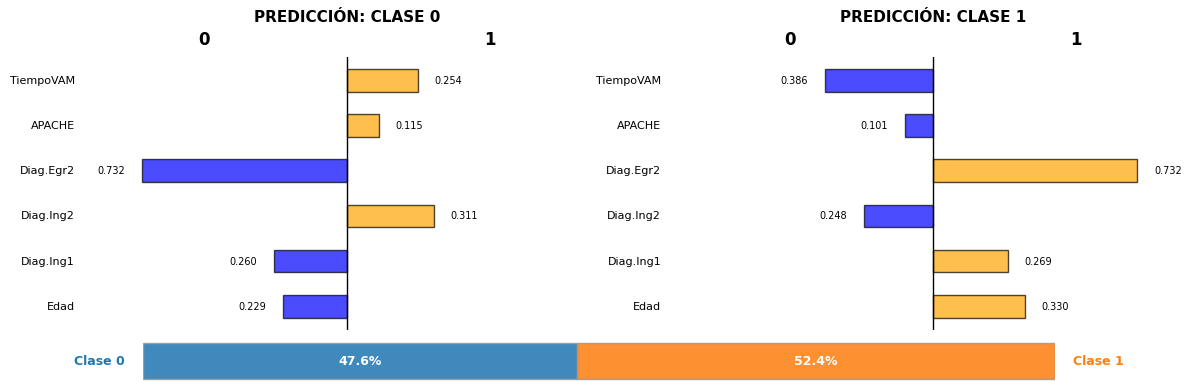

Weights: [np.float64(0.6008143584260965), np.float64(0.46152133776893395), np.float64(0.607735608082468), np.float64(0.47423659976438604)]
-1.437006335099037 0.7671902772234672


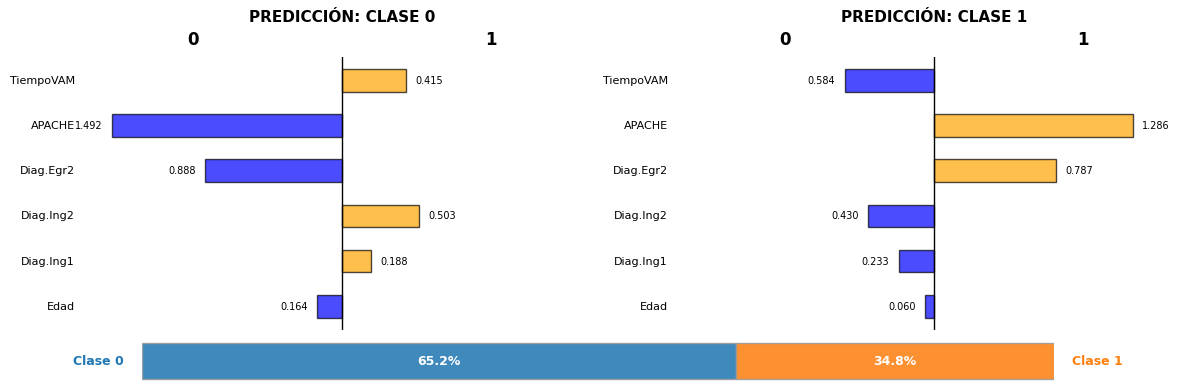

Weights: [np.float64(0.4969911116070924), np.float64(0.43325212858826606), np.float64(0.594446639159857), np.float64(0.5029295115782474)]
0.08383683971918166 -0.3019985356413268


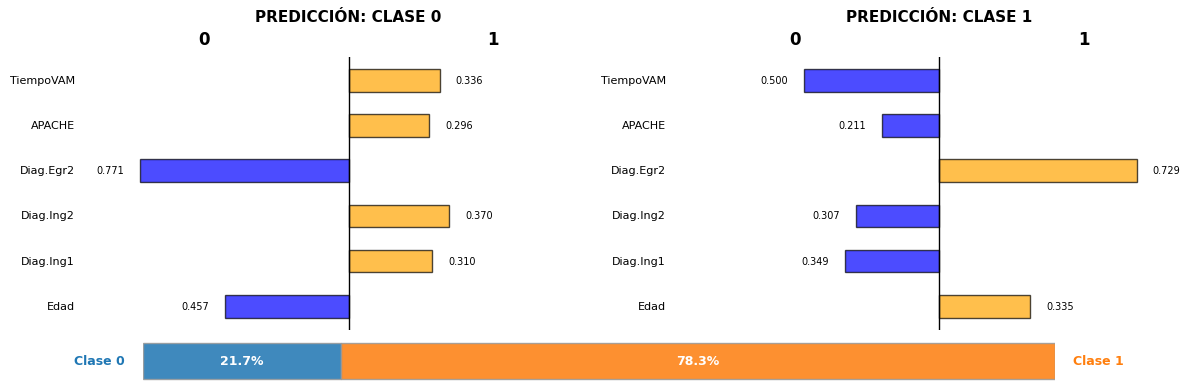

Weights: [np.float64(0.402113873957252), np.float64(0.16530777163673335), np.float64(0.582613519273793), np.float64(0.5548042487899736)]
1.809114786381968 -1.586570269950128


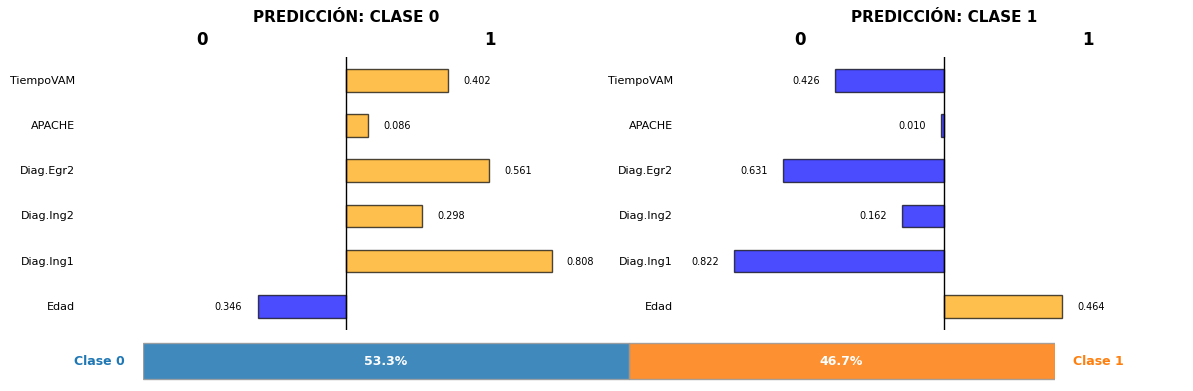

Weights: [np.float64(0.5257939237323104), np.float64(0.45229340904194276), np.float64(0.6557903475562966), np.float64(0.4653545075009126)]
-1.2238623033371425 0.8627127048964555


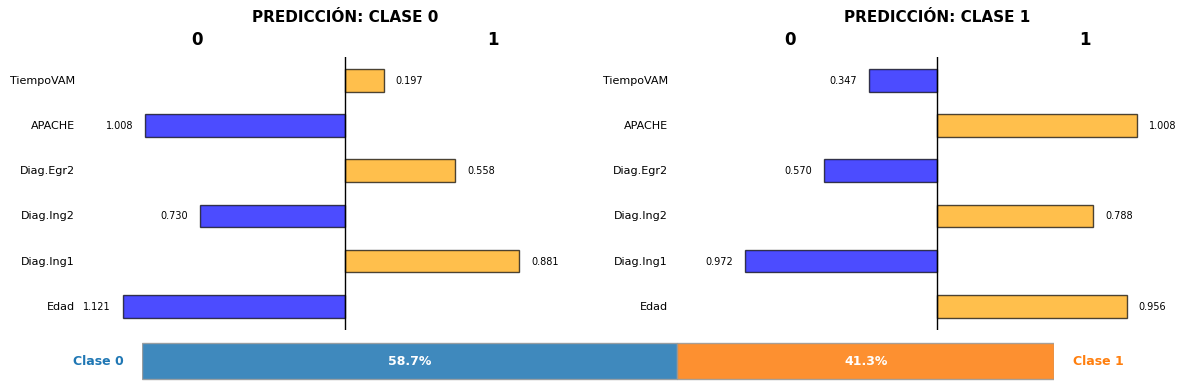

Weights: [np.float64(0.5447759190812442), np.float64(0.5200378252934091), np.float64(0.6956638087563292), np.float64(0.4354728841552702)]
-1.8604406235328137 2.007121711477819


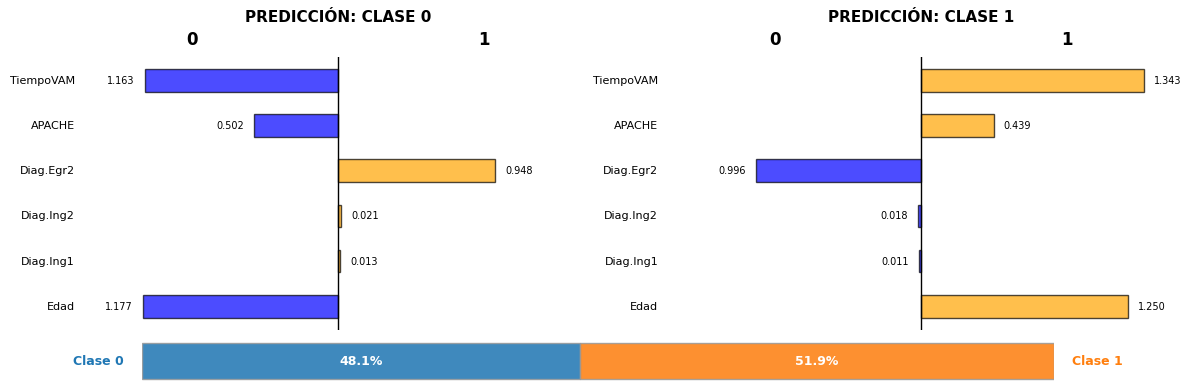

Weights: [np.float64(0.5047264447848842), np.float64(0.7265344554408925), np.float64(0.7302892410350057), np.float64(0.4866482817139531)]
-1.1319400403974909 0.5996936308646625


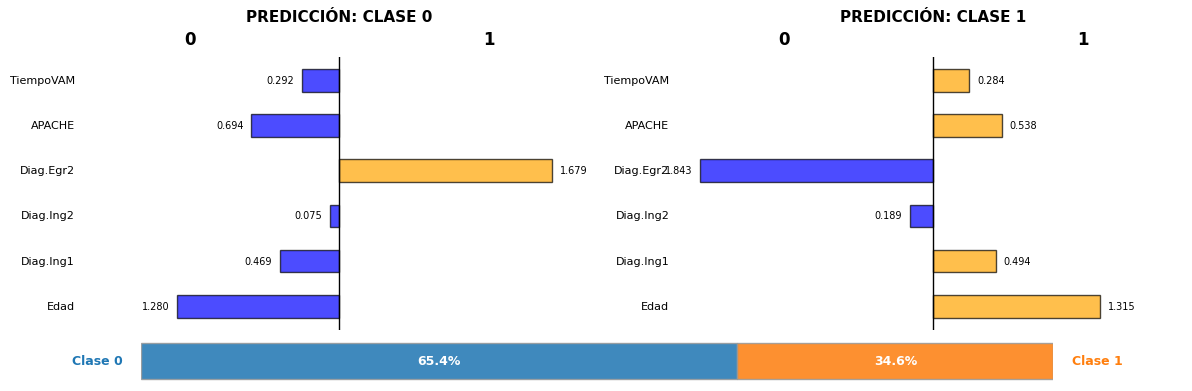

Weights: [np.float64(0.6318837654166264), np.float64(0.7166371955803107), np.float64(0.4964378655323218), np.float64(0.6759073075828472)]
-2.132620560870457 1.938195926242986


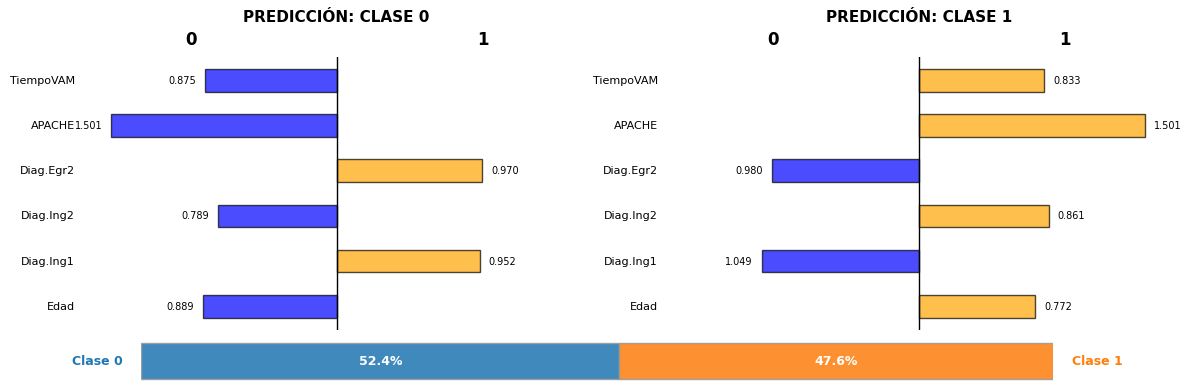

fidelity: [np.float64(0.994), np.float64(0.9405), np.float64(0.9556666666666667), np.float64(0.96675), np.float64(0.971), np.float64(0.9741666666666666), np.float64(0.9401428571428572), np.float64(0.947625)]

faithfulnessEstimate: [0.5268552195510359, 0.3773201730337039, -0.015544300138923904, 0.5558240717163083, -0.025148105147415955, 0.2716676082376777, 0.3635771797630637, -0.14385518024162147]

pixelFlipping: [0.7564509510993958, 2.8705692291259766, 1.9435789585113525, 4.332825183868408, 0.7892342805862427, 2.1030049324035645, 0.6990785598754883, 2.3375649452209473]

complexity: [np.float64(1.6289977567374938), np.float64(1.5220650443458539), np.float64(1.725894651638959), np.float64(1.6373584533604384), np.float64(1.7369907746824595), np.float64(1.3541674830009933), np.float64(1.5110902715645478), np.float64(1.7645735670969984)]

sparseness: [np.float64(0.29274719438057506), np.float64(0.403099636700425), np.float64(0.18697939005122383), np.float64(0.2966536757942306), np.float64(0

In [ ]:
# Use weighted sum
integrated_explanations_sum, integrated_explanations_sum_metric = owa_integrations.calculate_metric_integrated_explanations(
    explanations_data=new_explanations_data,
    instances_to_explain = instances_to_explain,
    metrics = metrics,
    model=model_pt,
    X = X,
    y = y,
    method="weighted_sum", #can be "weighted_sum", "weighted_average", or "simple_average"
    **kwargs,
)

Weights: [np.float64(0.4643279778348126), np.float64(0.3550542848557607), np.float64(0.42454539888950427), np.float64(0.2758859426343564)]
Class 0: 1 features with |value| > 0.85
Class 0: 1 features with |value| > 0.85
Class 0: 1 features with |value| > 0.85
Class 0: 1 features with |value| > 0.85
Class 1: 1 features with |value| > 0.85
Class 1: 1 features with |value| > 0.85
Class 1: 1 features with |value| > 0.85
Class 1: 1 features with |value| > 0.85
-0.9680417189457212 0.9680417189457212


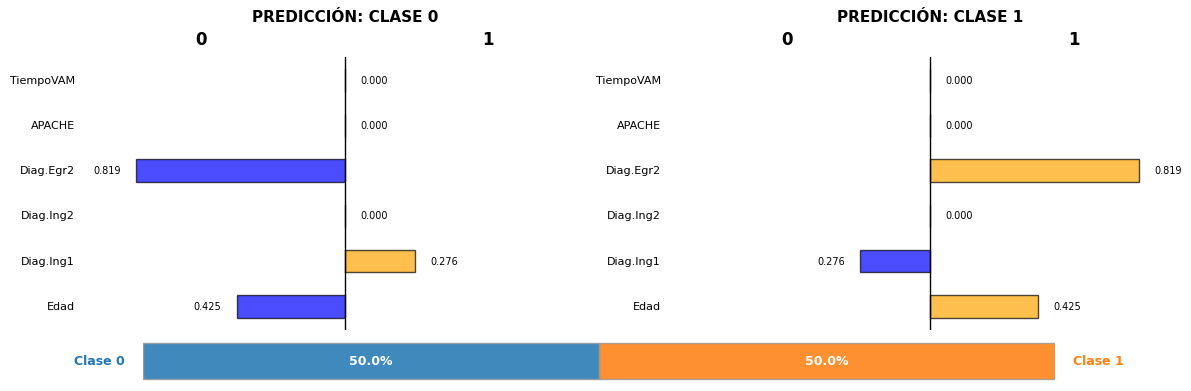

Weights: [np.float64(0.6008143584260965), np.float64(0.46152133776893395), np.float64(0.607735608082468), np.float64(0.47423659976438604)]
Class 0: 1 features with |value| > 0.85
Class 0: 2 features with |value| > 0.85
Class 0: 2 features with |value| > 0.85
Class 0: 1 features with |value| > 0.85
Class 1: 1 features with |value| > 0.85
Class 1: 2 features with |value| > 0.85
Class 1: 2 features with |value| > 0.85
Class 1: 1 features with |value| > 0.85
-1.246898075599197 0.33670469998812713


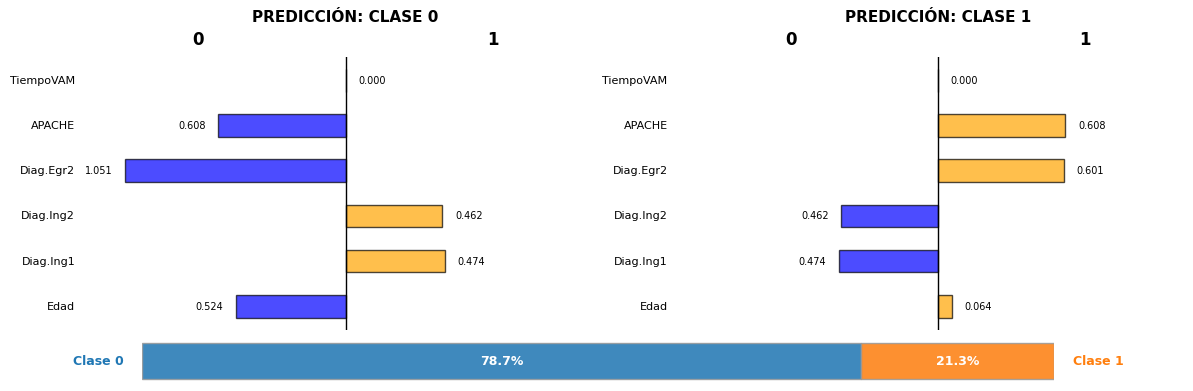

Weights: [np.float64(0.4969911116070924), np.float64(0.43325212858826606), np.float64(0.594446639159857), np.float64(0.5029295115782474)]
Class 0: 1 features with |value| > 0.85
Class 0: 3 features with |value| > 0.85
Class 0: 1 features with |value| > 0.85
Class 0: 1 features with |value| > 0.85
Class 1: 1 features with |value| > 0.85
Class 1: 3 features with |value| > 0.85
Class 1: 1 features with |value| > 0.85
Class 1: 1 features with |value| > 0.85
-0.1711878017506176 0.1675116752799819


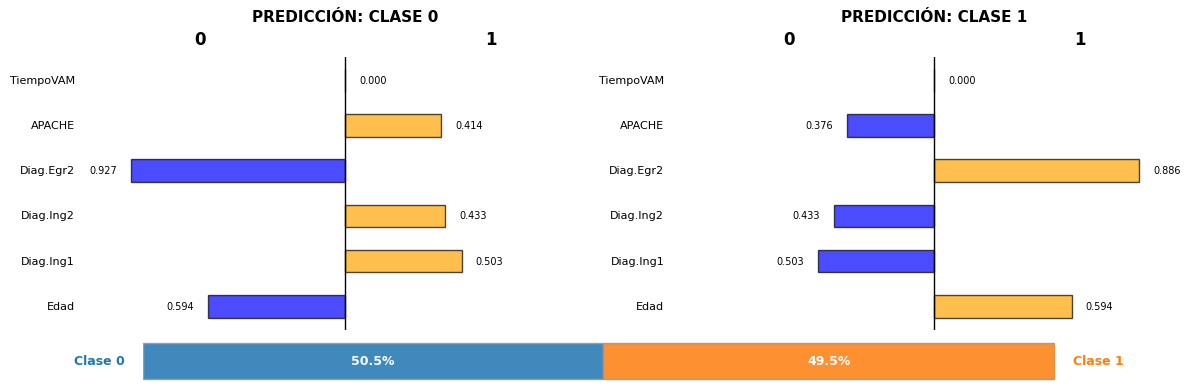

Weights: [np.float64(0.402113873957252), np.float64(0.16530777163673335), np.float64(0.582613519273793), np.float64(0.5548042487899736)]
Class 0: 2 features with |value| > 0.85
Class 0: 1 features with |value| > 0.85
Class 0: 1 features with |value| > 0.85
Class 0: 1 features with |value| > 0.85
Class 1: 1 features with |value| > 0.85
Class 1: 1 features with |value| > 0.85
Class 1: 1 features with |value| > 0.85
Class 1: 1 features with |value| > 0.85
0.9387325001574358 -0.539612375110166


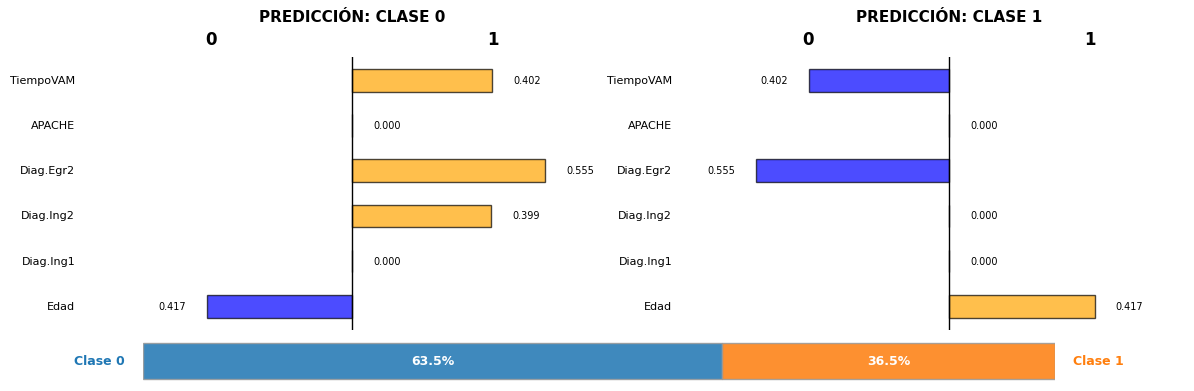

Weights: [np.float64(0.5257939237323104), np.float64(0.45229340904194276), np.float64(0.6557903475562966), np.float64(0.4653545075009126)]
Class 0: 1 features with |value| > 0.85
Class 0: 1 features with |value| > 0.85
Class 0: 1 features with |value| > 0.85
Class 0: 1 features with |value| > 0.85
Class 1: 1 features with |value| > 0.85
Class 1: 1 features with |value| > 0.85
Class 1: 1 features with |value| > 0.85
Class 1: 1 features with |value| > 0.85
-1.1685231728296372 1.1685231728296372


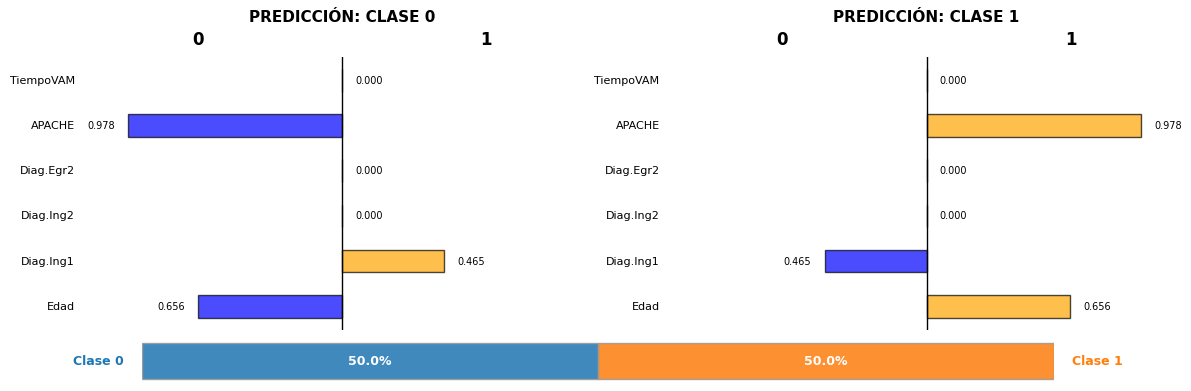

Weights: [np.float64(0.5447759190812442), np.float64(0.5200378252934091), np.float64(0.6956638087563292), np.float64(0.4354728841552702)]
Class 0: 1 features with |value| > 0.85
Class 0: 1 features with |value| > 0.85
Class 0: 1 features with |value| > 0.85
Class 0: 4 features with |value| > 0.85
Class 1: 2 features with |value| > 0.85
Class 1: 1 features with |value| > 0.85
Class 1: 1 features with |value| > 0.85
Class 1: 4 features with |value| > 0.85
-0.9201234983937188 1.4018631536540935


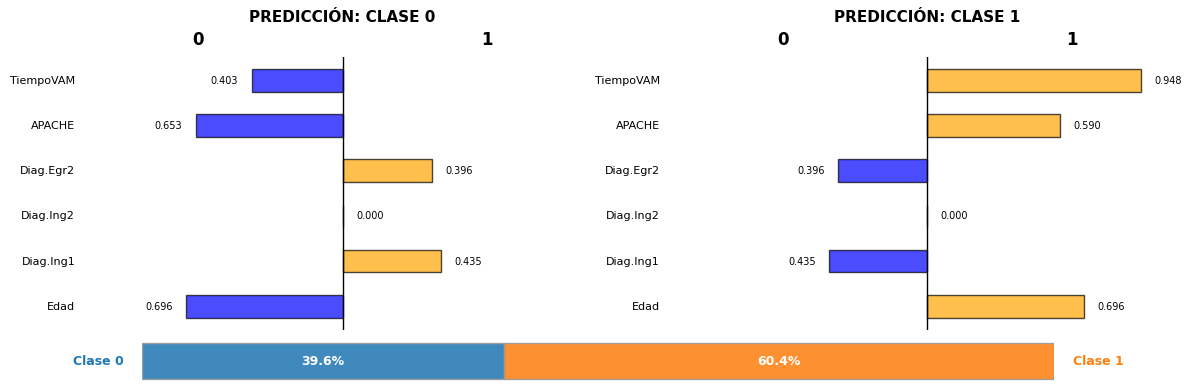

Weights: [np.float64(0.5047264447848842), np.float64(0.7265344554408925), np.float64(0.7302892410350057), np.float64(0.4866482817139531)]
Class 0: 1 features with |value| > 0.85
Class 0: 2 features with |value| > 0.85
Class 0: 1 features with |value| > 0.85
Class 0: 2 features with |value| > 0.85
Class 1: 1 features with |value| > 0.85
Class 1: 1 features with |value| > 0.85
Class 1: 1 features with |value| > 0.85
Class 1: 2 features with |value| > 0.85
-0.6466786973650335 -0.008535460095262959


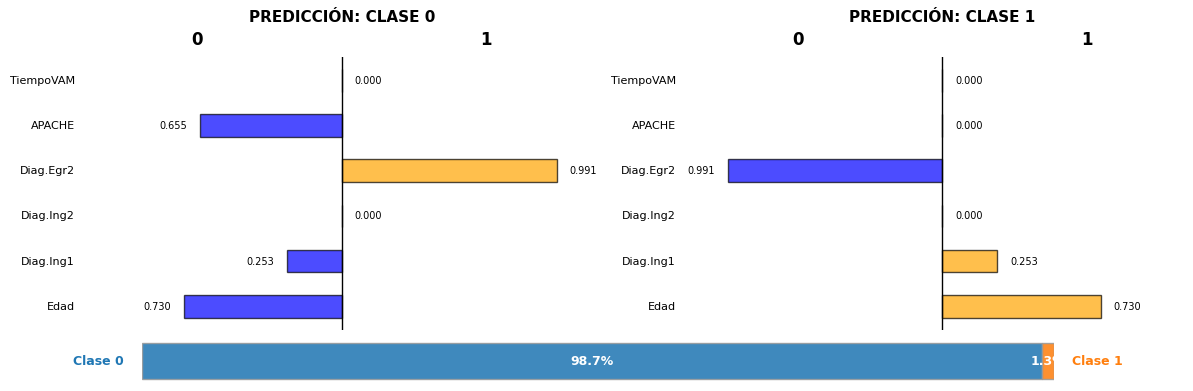

Weights: [np.float64(0.6318837654166264), np.float64(0.7166371955803107), np.float64(0.4964378655323218), np.float64(0.6759073075828472)]
Class 0: 1 features with |value| > 0.85
Class 0: 1 features with |value| > 0.85
Class 0: 1 features with |value| > 0.85
Class 0: 1 features with |value| > 0.85
Class 1: 2 features with |value| > 0.85
Class 1: 1 features with |value| > 0.85
Class 1: 1 features with |value| > 0.85
Class 1: 1 features with |value| > 0.85
-1.5279904030474625 0.9597164933398179


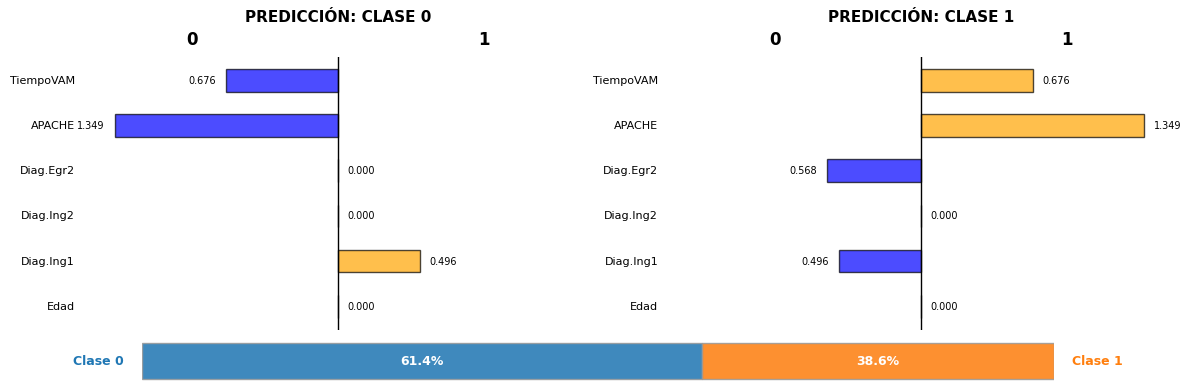

fidelity: [np.float64(0.998), np.float64(0.995), np.float64(0.9816666666666667), np.float64(0.98625), np.float64(0.9868), np.float64(0.9883333333333333), np.float64(0.9455714285714286), np.float64(0.945125)]

faithfulnessEstimate: [-0.11093817259776699, 0.24033088951597123, -0.006159704930316325, 0.4374382311431739, 0.16686428376484647, -0.012256804016130784, 0.3130752537283789, -0.27104931268011834]

pixelFlipping: [1.5178173780441284, 1.4057157039642334, 1.5311839580535889, 4.83847713470459, 0.7403759956359863, 3.660315752029419, 0.3993062376976013, 1.8211872577667236]

complexity: [np.float64(0.9990701792970295), np.float64(1.5540771491652867), np.float64(1.5607319363923975), np.float64(1.3761396299306896), np.float64(1.053273070710148), np.float64(1.5583488692101128), np.float64(0.9768323200696223), np.float64(1.2995742656436775)]

sparseness: [np.float64(0.6192020774864637), np.float64(0.3069914442567692), np.float64(0.30442047217581186), np.float64(0.3786565952888422), np.float64

In [ ]:
integrated_explanations_union, metric_integrated_union = union_owa_integrations.calculate_metric_union_integrated_explanations(
    explanations_data=new_explanations_data,
    instances_to_explain=instances_to_explain,
    metrics = metrics,
    model=model_pt,
    X = X,
    y = y,
    threshold=0.85,
    operator="sum", #'sum' , 'max'
    **kwargs
)

Class 0: 2 features in intersection (threshold=0.2)
Class 1: 2 features in intersection (threshold=0.2)
-0.14497236303196268 0.16824343556637014


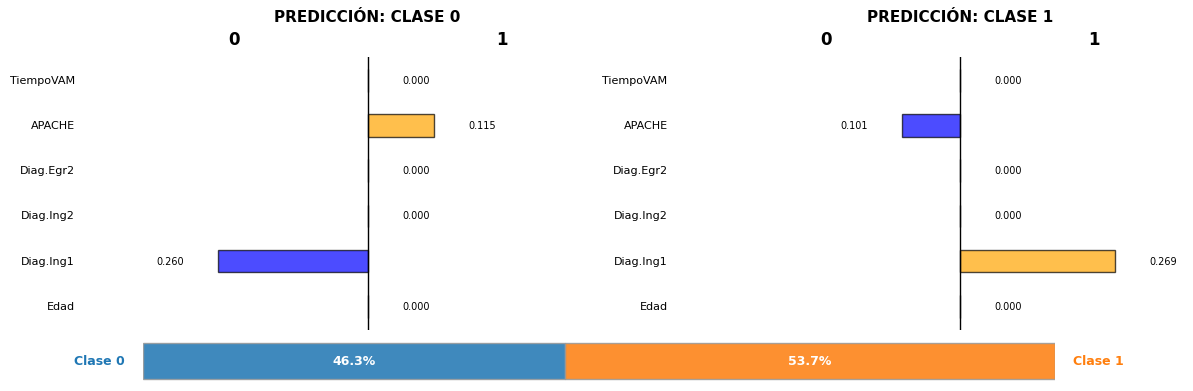

Class 0: 2 features in intersection (threshold=0.2)
Class 1: 2 features in intersection (threshold=0.2)
-1.3037564604155703 1.0534940205072292


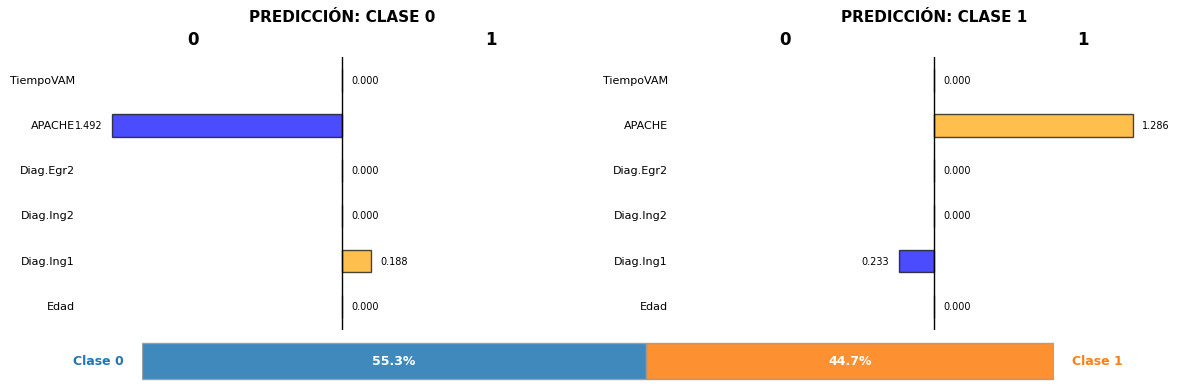

Class 0: 2 features in intersection (threshold=0.2)
Class 1: 2 features in intersection (threshold=0.2)
0.6059588361174806 -0.5598743656178617


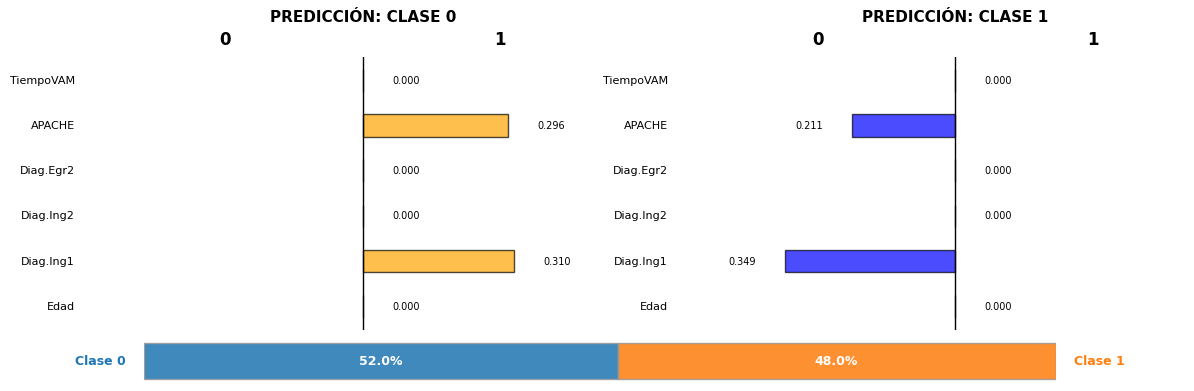

Class 0: 2 features in intersection (threshold=0.2)
Class 1: 2 features in intersection (threshold=0.2)
0.21507247251446904 -0.16704067872644368


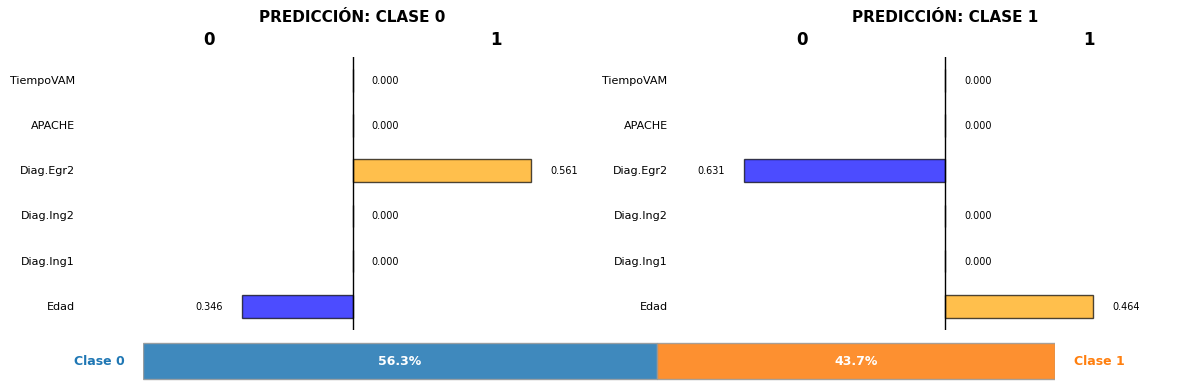

Class 0: 1 features in intersection (threshold=0.2)
Class 1: 2 features in intersection (threshold=0.2)
-0.7300454950596048 0.2179104534593348


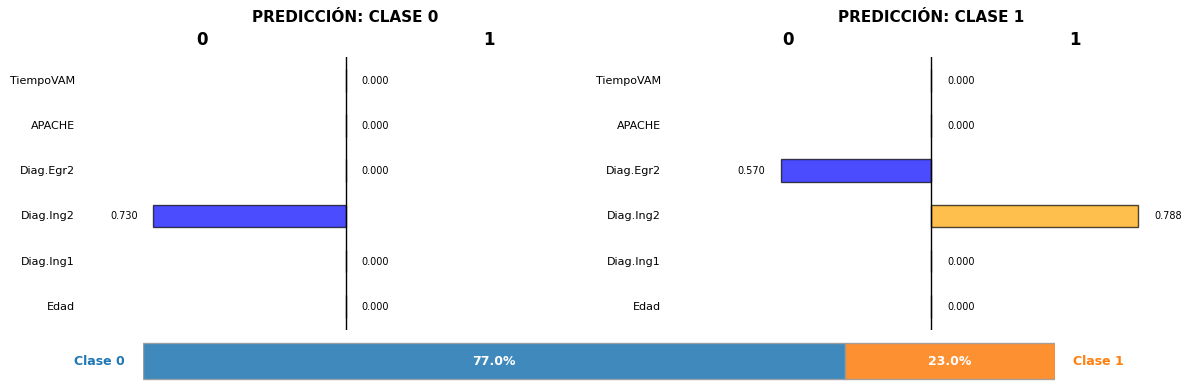

Class 0: 2 features in intersection (threshold=0.2)
Class 1: 2 features in intersection (threshold=0.2)
-1.665634898496793 1.7825461940969527


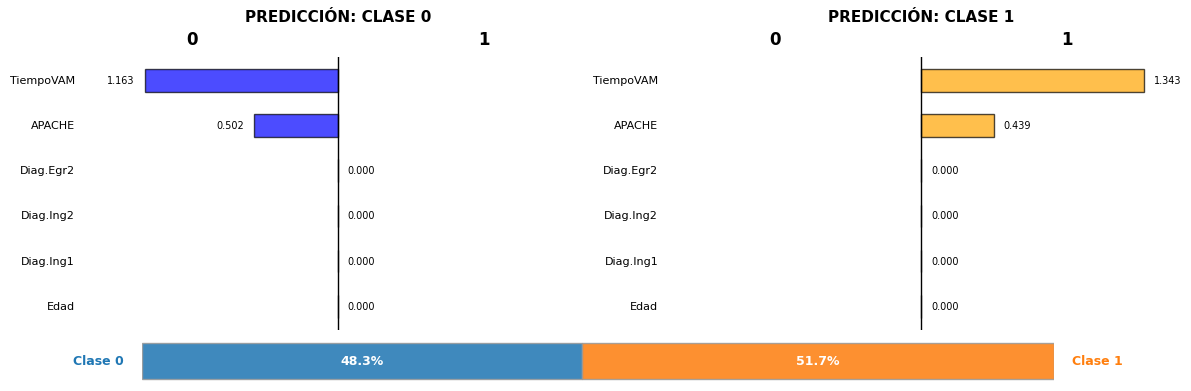

Class 0: 2 features in intersection (threshold=0.2)
Class 1: 2 features in intersection (threshold=0.2)
0.3984664102562647 -0.5275910922911522


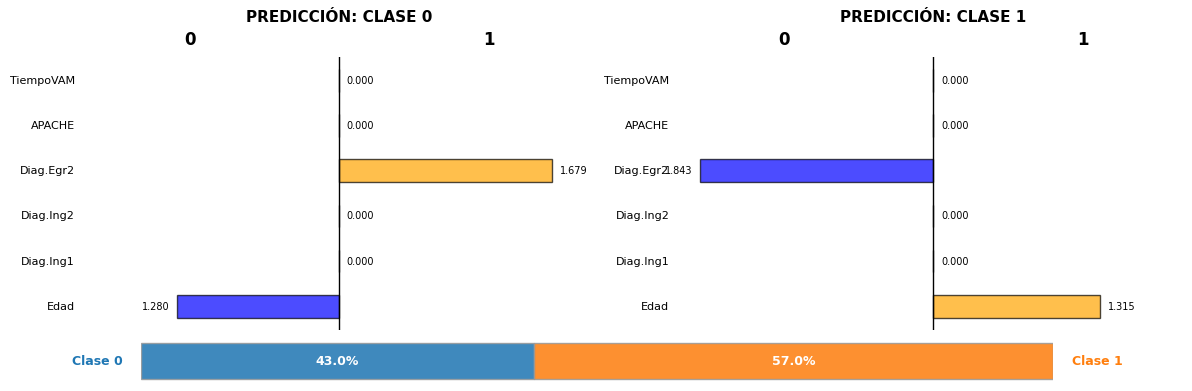

Class 0: 0 features in intersection (threshold=0.2)
Class 1: 0 features in intersection (threshold=0.2)
0.0 0.0


/content/drive/MyDrive/Tesis/Mortalidad_Oculta/Meta-Explainer/aux_functions.py:386: RuntimeWarning: invalid value encountered in scalar divide
  porcentaje0 = (abs(suma_clase0) / total) * 100
/content/drive/MyDrive/Tesis/Mortalidad_Oculta/Meta-Explainer/aux_functions.py:387: RuntimeWarning: invalid value encountered in scalar divide
  porcentaje1 = (abs(suma_clase1) / total) * 100


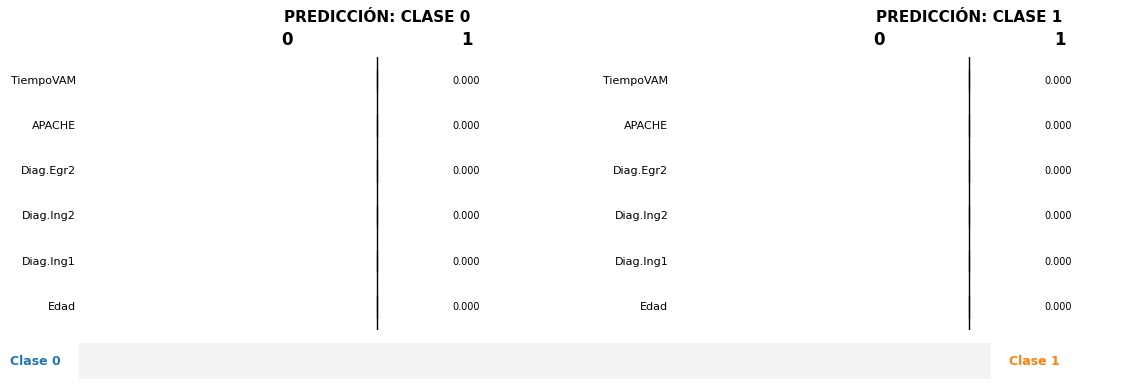

fidelity: [np.float64(0.993), np.float64(0.9025), np.float64(0.92), np.float64(0.94), np.float64(0.952), np.float64(0.96), np.float64(0.928), np.float64(0.928)]

faithfulnessEstimate: [0.5224866234452025, 0.1344593099516529, -0.588561571834984, -0.025547883948819062, -0.41246460976800897, -0.22737298868500438, 0.1737615604928906, nan]

pixelFlipping: [2.667998790740967, 4.379671573638916, 3.0484414100646973, 4.396918296813965, 0.7027720212936401, 2.371070384979248, 0.3993062376976013, 0.1584252566099167]

complexity: [np.float64(0.6161648345654849), np.float64(0.3505077176904558), np.float64(0.6928832040698438), np.float64(0.6647664555165099), np.float64(0.6802032309520398), np.float64(0.5584120861796565), np.float64(0.6791250355530283), np.float64(nan)]

sparseness: [np.float64(0.7312080559933084), np.float64(0.7960266431885481), np.float64(0.670494812670383), np.float64(0.7061845798826055), np.float64(0.6934242821310578), np.float64(0.7511796674891776), np.float64(0.6945117116068609)

/usr/local/lib/python3.12/dist-packages/quantus/functions/similarity_func.py:76: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return scipy.stats.pearsonr(a, b, axis=1)[0]
/usr/local/lib/python3.12/dist-packages/quantus/metrics/complexity/complexity.py:255: RuntimeWarning: invalid value encountered in divide
  a_batch /= np.abs(a_batch).sum(-1, keepdims=True)


In [ ]:
integrated_explanations_intersection, metric_integrated_intersection = intersection_owa_integrations.calculate_metric_intersection_integrated_explanations(
    explanations_data=new_explanations_data,
    instances_to_explain=instances_to_explain,
    metrics = metrics,
    model=model_pt,
    X = X,
    y = y,
    threshold = 0.2,
    operator = 'sum',
    **kwargs
)

## Representations

In [38]:
# Create a dictionary with the data
data = {
    'Metric_LIME': new_explanations_data[0]['metric'],
    'Metric_SHAP': new_explanations_data[1]['metric'],
    'Metric_IG': new_explanations_data[2]['metric'],
    'Metric_Saliencymaps': new_explanations_data[3]['metric'],
    'Metric_Integrated_W': integrated_explanations_sum_metric[0],
    'Metric_Union_W': metric_integrated_union,
    'Metric_Intersection_W': metric_integrated_intersection,
}

# Convert the dictionary into a DataFrame
df_metric = pd.DataFrame(data)
# Calculate the average of each column and add it as a new row
df_metric.loc['Average'] = df_metric.mean()

# Save the DataFrame to an Excel file
df_metric.to_excel("Tabular/Relevance/metric_values_relevance_integration.xlsx", index=False)

# Display the DataFrame
print(df_metric)

         Metric_LIME  Metric_SHAP  Metric_IG  Metric_Saliencymaps  \
0           0.464328     0.355054   0.424545             0.275886   
1           0.600814     0.461521   0.607736             0.474237   
2           0.496991     0.433252   0.594447             0.502930   
3           0.402114     0.165308   0.582614             0.554804   
4           0.525794     0.452293   0.655790             0.465355   
5           0.544776     0.520038   0.695664             0.435473   
6           0.504726     0.726534   0.730289             0.486648   
7           0.631884     0.716637   0.496438             0.675907   
Average     0.521428     0.478830   0.598440             0.483905   

         Metric_Integrated_W  Metric_Union_W  Metric_Intersection_W  
0                   0.466345        0.486439               0.425093  
1                   0.598808        0.265418               0.609137  
2                   0.331608        0.256861                    NaN  
3                   0.472625 

In [49]:
explanations_dict = {
    'LIME': new_explanations_data[0]['explanations'],
    'SHAP': new_explanations_data[1]['explanations'],
    'IG': new_explanations_data[2]['explanations'],
    'SaliencyMaps': new_explanations_data[3]['explanations'],
    'OWA': integrated_explanations_sum,
    'Unión': integrated_explanations_union,
    'Interseccción': integrated_explanations_intersection,
}

save_explanations_to_pkl(explanations_dict, "Tabular/Relevance/explanations_dict.pkl")

Explanations saved to Tabular/Relevance/explanations_dict.pkl


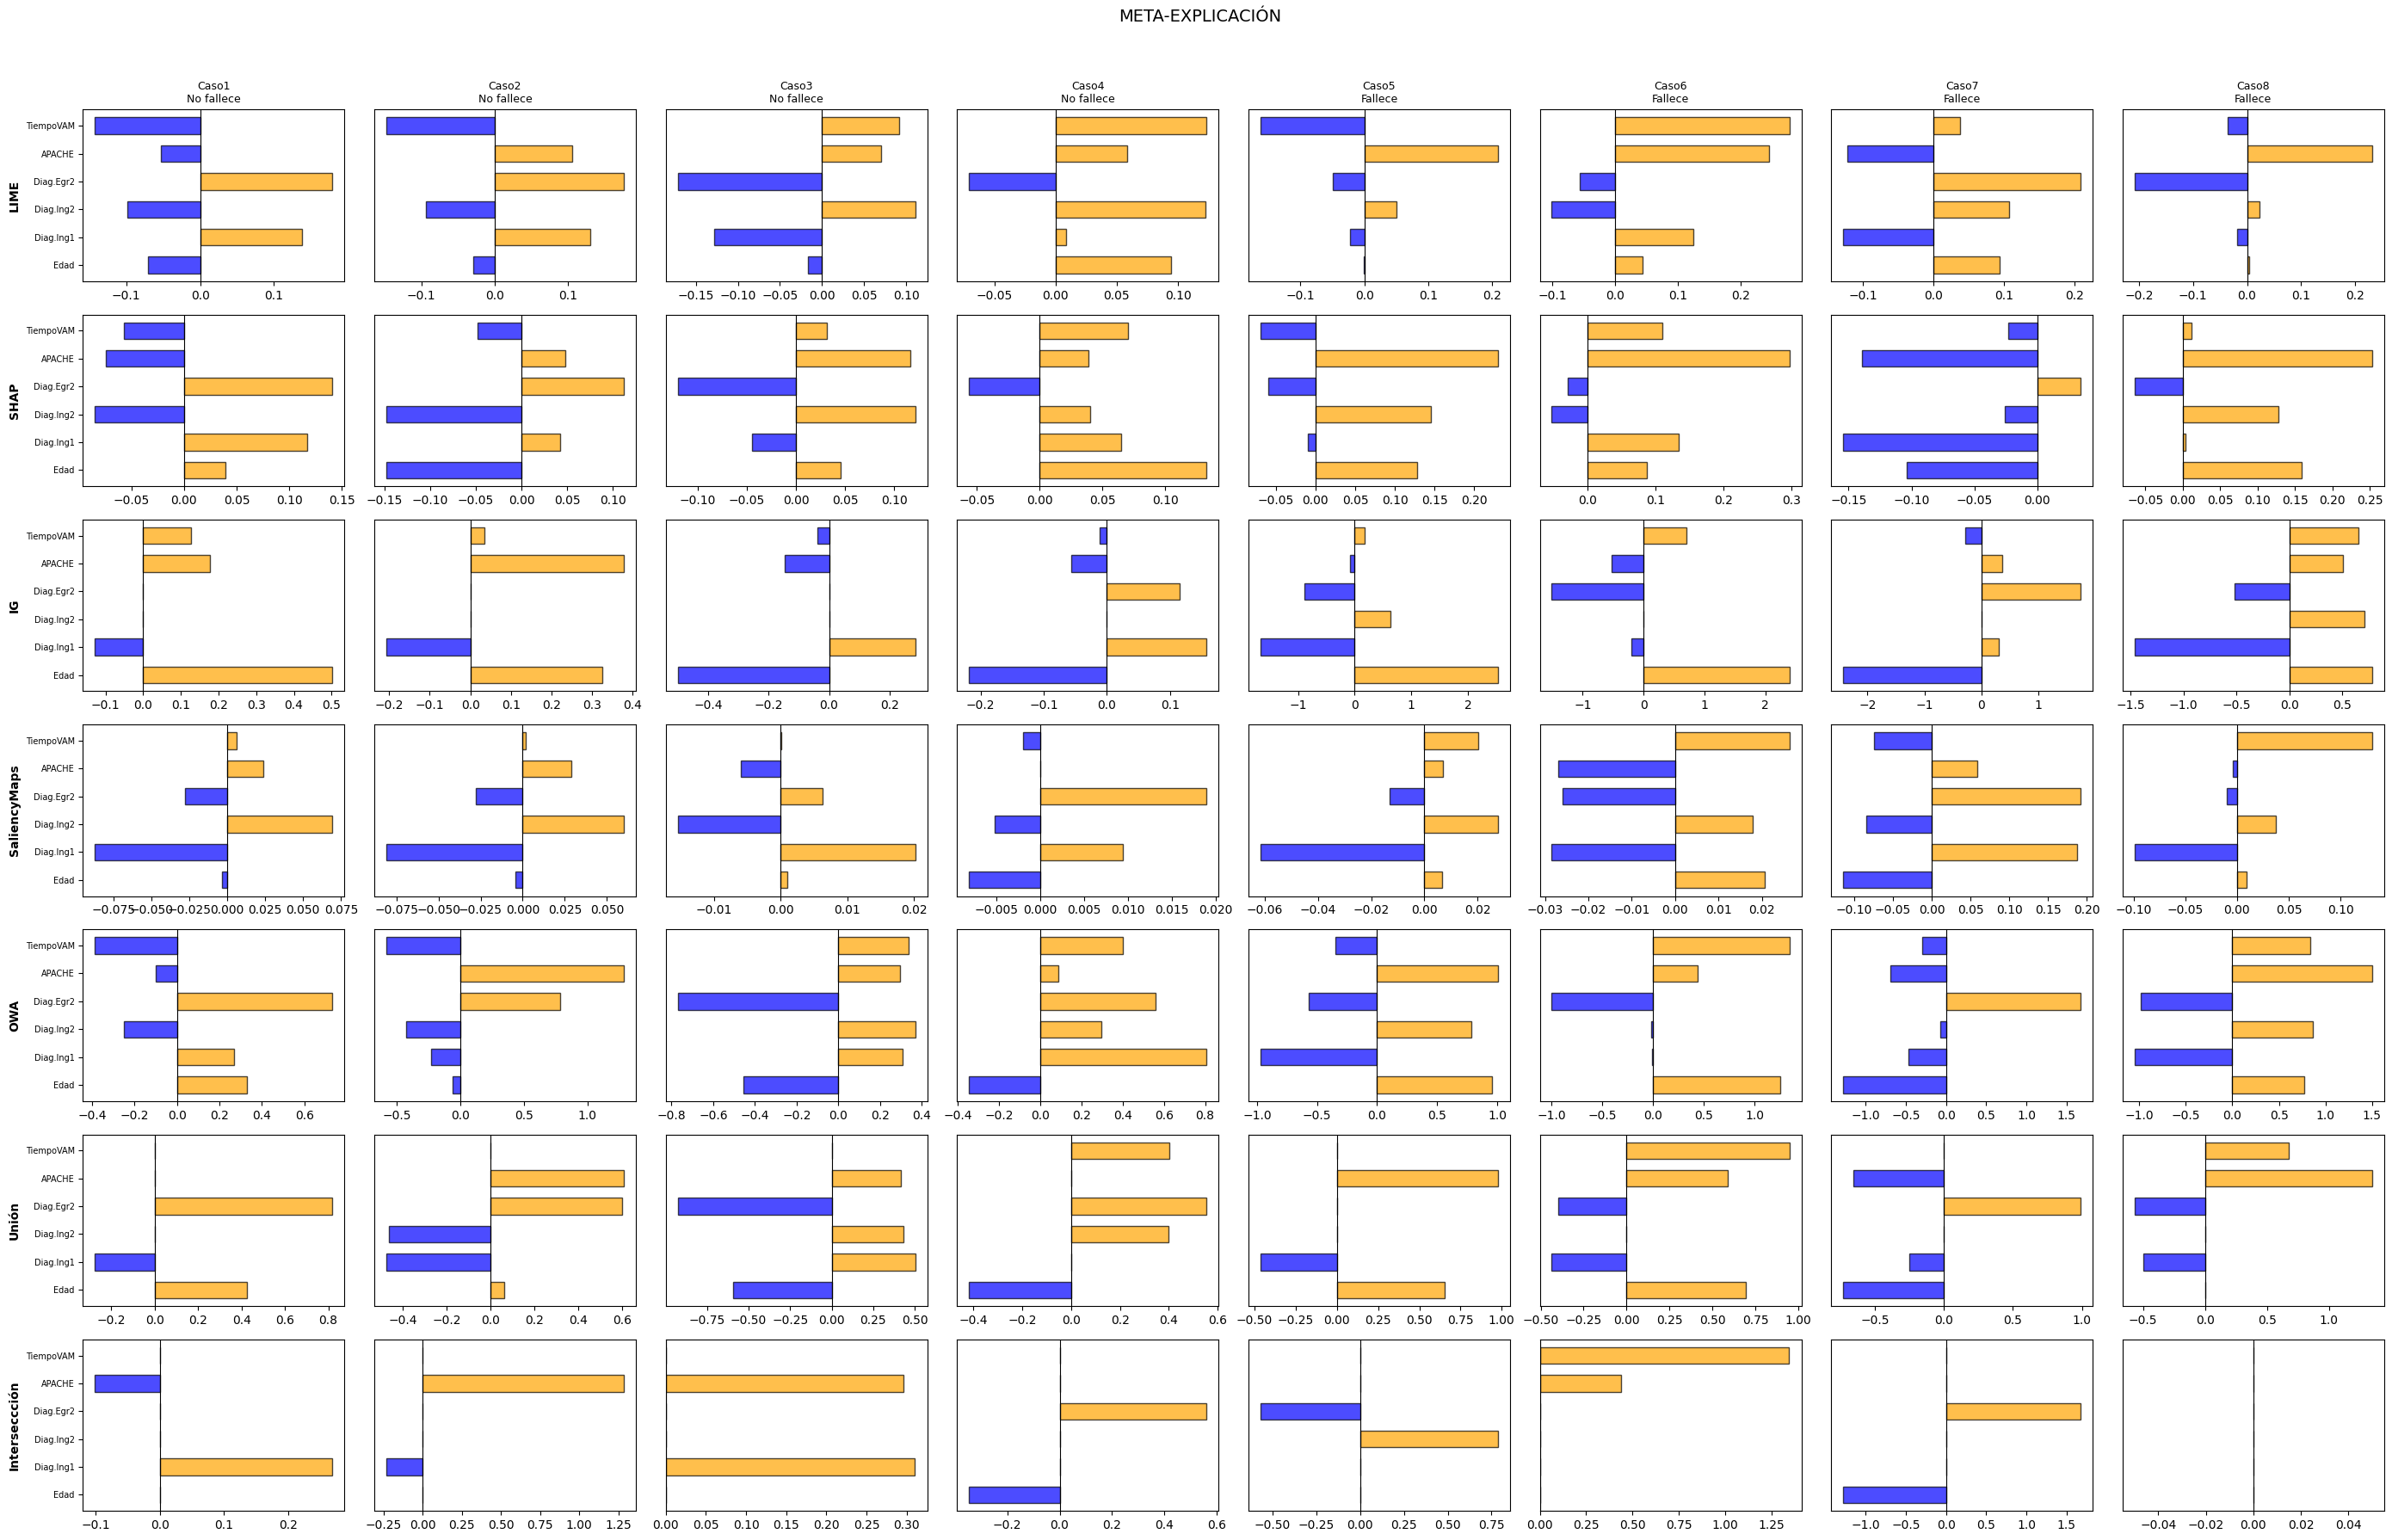

In [81]:
visualizar_explicaciones(
    all_explanations=explanations_dict,
    feature_names=X.columns.tolist(),
    y_true=y.iloc[instances_to_explain].values,
    model=model_pt,
    x_sel=X.iloc[instances_to_explain].values,
    n_clase0=4,
    n_clase1=4
)